# OneStream Help-Desk NLP Pipeline -- v2 (Unsupervised-First)
### KAN-CDSCO1002U -- NLP and Text Analytics | CBS BADS

**What changed from v1:**
- Removed all dependency on user-selected category column. User-selected
  categories are unreliable and introduce label noise (users mis-tag tickets).
- LDA now runs first and discovers topics purely from ticket language.
- LDA topic assignments become pseudo-labels for TF-IDF + Logistic Regression,
  which extracts the statistically most discriminative keywords per topic.
- Final output is a Dify-ready CSV: one row per intent class, with class
  descriptions formatted for direct paste into the QUESTION CLASSIFIER node.

**Architecture rationale (Jurafsky & Martin, 2014):**
The classifier sits between the user and the knowledge base. Its training
distribution must match its inference distribution -- real user language,
not internal category tags. LDA discovers clusters in that real language;
supervised feature extraction then identifies the most discriminative signal
within each cluster.

**Pipeline overview:**
| Phase | Task | Method |
|---|---|---|
| 0 | Setup + data loading | pandas, config |
| 1 | Preprocessing | spaCy lemmatisation, NLTK stopwords |
| 2 | Exploratory NLP | N-grams, NER, POS, VADER |
| 3 | LDA topic discovery | Gensim LDA, coherence sweep |
| 4 | Keyword extraction | TF-IDF + Logistic Regression on LDA labels |
| 5 | Semantic expansion | word2vec near-neighbours |
| 6 | Dify export | intent taxonomy CSV + routing recommendations |

**References:**
- Blei, D. M., Ng, A. Y., & Jordan, M. I. (2003). Latent Dirichlet allocation. *JMLR, 3*, 993-1022.
- Hutto, C. J., & Gilbert, E. (2014). VADER. *ICWSM*.
- Jurafsky, D., & Martin, J. H. (2014). *Speech and language processing* (3rd ed. draft).
- Manning, C. D., & Schütze, H. (2003). *Foundations of statistical natural language processing*. MIT Press.
- Mikolov, T., Chen, K., Corrado, G., & Dean, J. (2013). Efficient estimation of word representations in vector space. *arXiv:1301.3781*.

---
## Phase 0A -- Installation and Imports

In [1]:
# Install all required packages (run once)
# Only course-approved libraries are used throughout.
import subprocess, sys
pkgs = [
    'nltk', 'spacy', 'scikit-learn', 'gensim',
    'vaderSentiment', 'pyLDAvis', 'matplotlib',
    'seaborn', 'pandas', 'numpy', 'wordcloud'
]
for p in pkgs:
    subprocess.run([sys.executable, '-m', 'pip', 'install', p, '-q'], check=False)
subprocess.run([sys.executable, '-m', 'spacy', 'download', 'en_core_web_md', '-q'], check=False)
print('All packages ready.')


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip3 install --upgr

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
All packages ready.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [2]:
# Core imports
import re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
warnings.filterwarnings('ignore')

# NLTK -- tokenisation, n-grams, POS, stopwords (Lectures 1-3)
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk import FreqDist, pos_tag
from nltk.util import ngrams as make_ngrams
nltk.download(['punkt', 'stopwords', 'wordnet',
               'averaged_perceptron_tagger', 'omw-1.4'], quiet=True)

# spaCy -- lemmatisation, NER, POS (Lab 02, 03, 04)
import spacy
nlp = spacy.load('en_core_web_md')

# scikit-learn -- TF-IDF, classifiers, evaluation (Lab 05, 06, MA2)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score)
from sklearn.metrics.pairwise import cosine_similarity

# Gensim -- LDA, word2vec (Lab 07)
import gensim
from gensim import corpora
from gensim.models import CoherenceModel, Word2Vec

# VADER -- sentiment analysis (Lecture 5, MA2)
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

from wordcloud import WordCloud

# Global plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 130, 'figure.figsize': (10, 4)})
BRAND_COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52',
                '#8172B3', '#937860', '#DA8BC3', '#8C8C8C']

print('All imports successful.')

[nltk_data] <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED]
[nltk_data]     certificate verify failed: unable to get local issuer
[nltk_data]     certificate (_ssl.c:1032)>


All imports successful.


---
## Phase 0B -- Data Loading

**This is the ONLY cell you need to edit before running.**

Set `FILE_PATH` and `TEXT_COL`. There is NO label/category column --
this pipeline discovers intent classes entirely from ticket text.

If you have both a subject line and a description column, concatenate
them using the commented lines below -- more text per document gives
LDA a much better signal.

In [11]:
# ====================================================================
# EDIT HERE -- only these values need to change
# ====================================================================
FILE_PATH = '/Users/linusstamovyu/Downloads/OS/Helpdesk(in).csv'              # <- path to your CSV file
TEXT_COL  = 'TicketIssue'  # <- column containing the user-written ticket body
ID_COL    = 'TicketID'    # <- unique ticket ID column (set to None if absent)
# ====================================================================

# Optional: concatenate subject + description for richer documents
# SUBJECT_COL = 'subject'
# DESC_COL    = 'description'
# df[TEXT_COL] = df[SUBJECT_COL].fillna('') + ' ' + df[DESC_COL].fillna('')

df = pd.read_csv(FILE_PATH)
print(f'Loaded {len(df):,} tickets')
print(f'Columns: {df.columns.tolist()}')
df.head()

Loaded 1,828 tickets
Columns: ['TicketID', 'TicketPriority', 'TicketIssue', 'TicketUser', 'TicketOpenTime', 'TicketClosedTime', 'TicketStatus', 'TicketResponse', 'TicketOwner', 'TicketCategory', 'APMM_TicketNumber', 'APMM_BusinessUnit', 'APMM_ResolutionType', 'APMM_ResolutionExp', 'APMM_Impact', 'APMM_TicketComms', 'APMM_LastUpdateTime', 'APMM_ReportingType', 'APMM_L1Time', 'APMM_L2Time']


,TicketID,TicketPriority,TicketIssue,TicketUser,TicketOpenTime,TicketClosedTime,TicketStatus,TicketResponse,TicketOwner,TicketCategory,APMM_TicketNumber,APMM_BusinessUnit,APMM_ResolutionType,APMM_ResolutionExp,APMM_Impact,APMM_TicketComms,APMM_LastUpdateTime,APMM_ReportingType,APMM_L1Time,APMM_L2Time
0,d8f5db1b-aea6-4430-ad64-00a8ab91fa57,3,"ID001L megered to ID04 in Mar 2024, but still ...",XLI086,2/5/2025 13:45,2/5/2025 13:55,40,NaN,PSS009,Data,OS_2025020030,BU_LS,40,NaN,2,~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~...,2/5/2025 13:55,Actuals,0,15
1,4cc23b67-c7d8-4858-9dac-00e2b0c88a88,1,"Hi team,\r\n\r\nCould you please confirm if ca...",STD002,2/26/2026 9:26,1/1/1900 0:00,20,NaN,SBP019,IFRS16,OS_2026020095,BU_MaerskLine,10,NaN,1,~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~...,2/26/2026 9:37,Actuals,0,0
2,016e30c8-9fcd-41c7-bf99-010e56fc0569,2,Requesting access to LS_CFO_and_Financial_Cont...,YOS014,2/27/2025 15:34,2/28/2025 7:17,40,NaN,RBH129,Other,OS_2025020088,BU_LS,30,NaN,1,~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~...,2/28/2025 7:17,NaN,0,0
3,09e67784-2fc5-47ce-950c-0131110f2ecd,3,HSUD entities - we are facing an error to uplo...,DLU046,2/1/2024 10:43,2/1/2024 12:17,40,NaN,RGA146,Workflows,OS_2024020008,BU_MaerskLine,50,"Before check user has confirmed that , they ar...",2,~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~...,2/1/2024 12:17,Actuals,0,5
4,e88a79ac-37bb-4242-bf60-0157dcf0afc4,1,"Hi Team,\r\nCan you please provide BU_MaerskLi...",ARA167,3/21/2024 12:26,3/22/2024 12:11,40,NaN,SDN004,Data,OS_2024030048,BU_MaerskLine,50,NaN,2,~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~...,3/22/2024 12:11,Actuals,0,30


In [13]:
# Dataset health check
# Purpose : surface data quality issues before modelling begins.
# Ref     : Jurafsky & Martin (2014), Ch. 4 -- training data quality.

print('=' * 55)
print('DATASET HEALTH CHECK')
print('=' * 55)
print(f'Total tickets         : {len(df):,}')
print(f'Missing text values   : {df[TEXT_COL].isna().sum()}')

df = df.dropna(subset=[TEXT_COL]).reset_index(drop=True)
df['raw_token_len'] = df[TEXT_COL].str.split().str.len()

print(f'\nTicket length (words):')
print(df['raw_token_len'].describe().round(1).to_string())

short_count = (df['raw_token_len'] < 5).sum()
if short_count > 0:
    print(f'\nWARNING: {short_count} tickets have fewer than 5 tokens.')
    print('  LDA cannot reliably assign these to a topic.')
    print('  Consider concatenating subject + description columns.')

if len(df) < 200:
    print(f'\nWARNING: Only {len(df)} tickets. LDA needs >= 200 for stable topics.')
    print('  Reduce TOPIC_RANGE upper bound and treat results as directional.')

print(f'\nUsable tickets: {len(df):,}')

DATASET HEALTH CHECK
Total tickets         : 1,828
Missing text values   : 0

Ticket length (words):
count    1828.0
mean       19.1
std        16.8
min         1.0
25%         8.0
50%        14.0
75%        25.0
max       190.0

  LDA cannot reliably assign these to a topic.
  Consider concatenating subject + description columns.

Usable tickets: 1,828


In [51]:
short_tickets = df[df['raw_token_len'] < 5][['TicketID', 'TicketIssue', 'raw_token_len']]

print(f'Tickets with fewer than 5 tokens: {len(short_tickets)}')
print('='*60)
for _, row in short_tickets.iterrows():
    print(f"ID: {row['TicketID']}  |  Text: {row['TicketIssue']}")

Tickets with fewer than 5 tokens: 105
ID: c8506ae8-c08e-4c86-b22e-03068ccd0289  |  Text: https://10.74.32.197/OneStreamWeb - Access required
ID: 58a94055-6b3b-4050-8b33-034b71368088  |  Text: CZ005L Star Container
ID: f445534f-2bf8-4848-9691-06a83f02e7d9  |  Text: TR008U IFRS16 Expired Contract
ID: 8cb18c20-5706-49da-b03b-0a6af068f7dd  |  Text: Query on lease extension
ID: 1574d399-8471-47f8-b58c-1137c186744b  |  Text: TEST
ID: f261e62e-ebde-416f-a16c-11809726bd44  |  Text: Lease error
ID: 0dc4b233-3d39-4a27-bf6f-11c255462d84  |  Text: Lease calculation showing error
ID: c8a0cdaf-cd79-465e-9469-11fac6af260a  |  Text: Need access for //10.74.32.198/onestreamweb
ID: 8b8af064-69f3-4bf7-9a8e-13ba5b4483d7  |  Text: lease payment calculation
ID: c20bb7b4-a621-418c-9249-141c012c5079  |  Text: TR008U IFRS16 Expired Contract
ID: 484b0870-e75a-4fe1-af9e-19a6b9ddc6cd  |  Text: EG013L Certification Access
ID: d96155ba-3d38-412c-8535-1c0fde2950c1  |  Text: LK001L IFFRS Interface issue
ID: ea643dfc-

Can we make a slecial fix for just these if htey are overrepresentated.

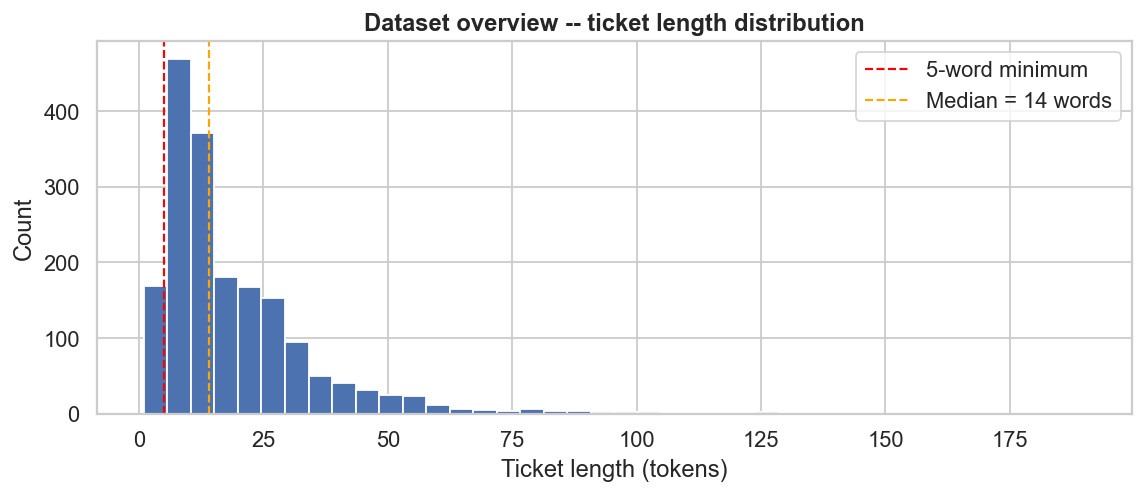

Saved: fig_00_dataset_overview.png


In [14]:
# Visual: ticket length distribution
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df['raw_token_len'], bins=40, color=BRAND_COLORS[0], edgecolor='white')
ax.axvline(5, color='red', linestyle='--', linewidth=1.2,
           label='5-word minimum')
ax.axvline(df['raw_token_len'].median(), color='orange', linestyle='--',
           linewidth=1.2,
           label=f'Median = {df["raw_token_len"].median():.0f} words')
ax.set_xlabel('Ticket length (tokens)')
ax.set_ylabel('Count')
ax.set_title('Dataset overview -- ticket length distribution', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig_00_dataset_overview.png', bbox_inches='tight')
plt.show()
print('Saved: fig_00_dataset_overview.png')

---
## Phase 1 -- Data Preprocessing

**Goal:** Convert raw ticket text into a clean, normalised corpus.

**Techniques:**
- Lowercasing, punctuation removal -- Lecture 2
- NLTK stopword removal + domain-specific extension -- Lecture 2
- spaCy lemmatisation (preferred over NLTK stemmer -- Lab 02 comparison)

**Why domain stopwords matter for LDA:** Generic support words ('please',
'issue', 'help') appear in every topic and make all topics look the same.
Removing them forces LDA to differentiate on substantive content words.

> Manning & Schütze (2003): text normalisation is a prerequisite for
> meaningful frequency-based analysis.

In [15]:
# Preprocessing pipeline
# Input : raw ticket string
# Output: cleaned, lemmatised string ready for TF-IDF or LDA
# Ref   : Manning & Schütze (2003), Ch. 2; Lab 02

STOPWORDS = set(stopwords.words('english'))

# OneStream domain stopwords -- generic IT-support words that carry no
# discriminative intent signal. Extend this list after reviewing your data.
DOMAIN_STOPWORDS = {
    # Greeting / politeness
    'hi', 'hello', 'dear', 'regards', 'thanks', 'thank',
    'please', 'kindly', 'sincerely',
    # Generic support language -- appear in EVERY intent class equally
    'ticket', 'issue', 'problem', 'help', 'need', 'using',
    'user', 'client', 'team', 'support', 'request', 'able',
    'unable', 'work', 'working', 'let', 'know', 'get',
    # System noise
    'onestream', 'system', 'application', 'app'
}
STOPWORDS = STOPWORDS | DOMAIN_STOPWORDS

# Short domain abbreviations to keep even though len <= 2 chars
KEEP_TOKENS = {'id', 'ui', 'db', 'api', 'qa', 'fx', 'bi'}


def clean_ticket(text: str) -> str:
    """
    Preprocessing pipeline for a single ticket string.

    Steps
    -----
    1. Lowercase.
    2. Strip HTML, URLs, emails, ticket metadata ([TICKET-001]).
    3. Remove punctuation and digits.
    4. spaCy lemmatisation.
    5. Remove stopwords and short tokens (< 3 chars unless in KEEP_TOKENS).

    Returns: space-joined string of cleaned lemmas.
    """
    if not isinstance(text, str) or len(text.strip()) == 0:
        return ''
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)      # HTML tags
    text = re.sub(r'\[.*?\]', ' ', text)      # [TICKET-001] patterns
    text = re.sub(r'http\S+', ' ', text)       # URLs
    text = re.sub(r'\S+@\S+', ' ', text)       # email addresses
    text = re.sub(r'[^a-z\s]', ' ', text)     # keep letters and spaces only
    text = re.sub(r'\s+', ' ', text).strip()
    doc = nlp(text, disable=['ner', 'parser'])  # disable unused pipes for speed
    tokens = [
        t.lemma_.strip()
        for t in doc
        if (
            t.lemma_.strip() not in STOPWORDS
            and (len(t.lemma_) > 2 or t.text in KEEP_TOKENS)
        )
    ]
    return ' '.join(tokens)


print('Running spaCy pipeline -- may take 1-3 min for large datasets...')
df['clean_text'] = df[TEXT_COL].apply(clean_ticket)

empty_after = (df['clean_text'].str.strip() == '').sum()
if empty_after:
    print(f'WARNING: {empty_after} tickets became empty after cleaning -- dropping.')
df = df[df['clean_text'].str.strip() != ''].reset_index(drop=True)

df['tokens'] = df['clean_text'].str.split()  # list-of-lists for Gensim LDA
df['clean_token_len'] = df['tokens'].str.len()

print(f'Preprocessing complete.  {len(df):,} usable tickets.')
print('\nBefore vs After -- token length stats:')
print(pd.DataFrame({
    'Before cleaning': df['raw_token_len'].describe(),
    'After cleaning':  df['clean_token_len'].describe()
}).round(1))
print('\nSample (raw --> clean):')
for i in range(min(3, len(df))):
    print(f'  RAW  : {str(df[TEXT_COL].iloc[i])[:80]}')
    print(f'  CLEAN: {df["clean_text"].iloc[i][:80]}\n')

Running spaCy pipeline -- may take 1-3 min for large datasets...
Preprocessing complete.  1,826 usable tickets.

Before vs After -- token length stats:
       Before cleaning  After cleaning
count           1826.0          1826.0
mean              19.2             9.3
std               16.8             7.7
min                1.0             1.0
25%                8.0             4.0
50%               14.0             7.0
75%               25.0            12.0
max              190.0            77.0

Sample (raw --> clean):
  RAW  : ID001L megered to ID04 in Mar 2024, but still have amount in Jan 2025, please as
  CLEAN: megere mar still amount jan assist clearing certify

  RAW  : Hi team,

Could you please confirm if calculation of  Service element of lease
  CLEAN: could confirm calculation service element lease base number day base something e

  RAW  : Requesting access to LS_CFO_and_Financial_Controller for Dashboard, cube view an
  CLEAN: access cfo financial controller dashboard 

---
## Phase 2 -- Exploratory NLP

**Goal:** Surface high-frequency patterns, named entities, and structural
characteristics of user queries before modelling.

**Techniques:**
- N-gram frequency (Jurafsky & Martin, 2014, Ch. 4; Lecture 2)
- Named Entity Recognition -- spaCy (Lab 02, 03)
- POS tagging -- NLTK (Lecture 2; Lab 02)
- VADER sentiment for escalation routing (Hutto & Gilbert, 2014; Lecture 5; MA2)

In [16]:
# 2A: N-gram frequency analysis
# Purpose : identify most common words and multi-word expressions.
# Frequent bigrams are strong candidates for classifier keywords.
# Ref     : Jurafsky & Martin (2014), Ch. 4

all_tokens   = [t for doc in df['tokens'] for t in doc]
unigram_fd   = FreqDist(all_tokens)
top_uni      = pd.DataFrame(unigram_fd.most_common(30), columns=['word', 'count'])

all_bigrams  = list(make_ngrams(all_tokens, 2))
bigram_fd    = FreqDist(all_bigrams)
top_bigrams  = pd.DataFrame(
    [(' '.join(b), c) for b, c in bigram_fd.most_common(30)],
    columns=['bigram', 'count']
)

all_trigrams = list(make_ngrams(all_tokens, 3))
trigram_fd   = FreqDist(all_trigrams)
top_trigrams = pd.DataFrame(
    [(' '.join(t), c) for t, c in trigram_fd.most_common(15)],
    columns=['trigram', 'count']
)

print('Top 20 unigrams:')
print(top_uni.head(20).to_string(index=False))
print('\nTop 15 bigrams:')
print(top_bigrams.head(15).to_string(index=False))
print('\nTop 10 trigrams:')
print(top_trigrams.head(10).to_string(index=False))

Top 20 unigrams:
      word  count
     lease    606
      test    461
    access    455
    entity    445
     error    275
    server    239
    report    215
     datum    191
      open    191
    period    183
   account    178
     check    166
      ifrs    159
    attach    157
    module    147
     month    114
    update    106
   provide    103
   sandbox    103
validation    101

Top 15 bigrams:
            bigram  count
       test server    196
       access test    105
      lease module     80
  test environment     60
         imea imea     59
        ifrs lease     55
     server access     55
intersection error     53
       open period     43
        one stream     41
    tst changerequ     40
    provide access     37
       test module     34
         new lease     31
      lease report     30

Top 10 trigrams:
                 trigram  count
          imea imea imea     54
      test server access     48
      access test server     41
 access test environment  

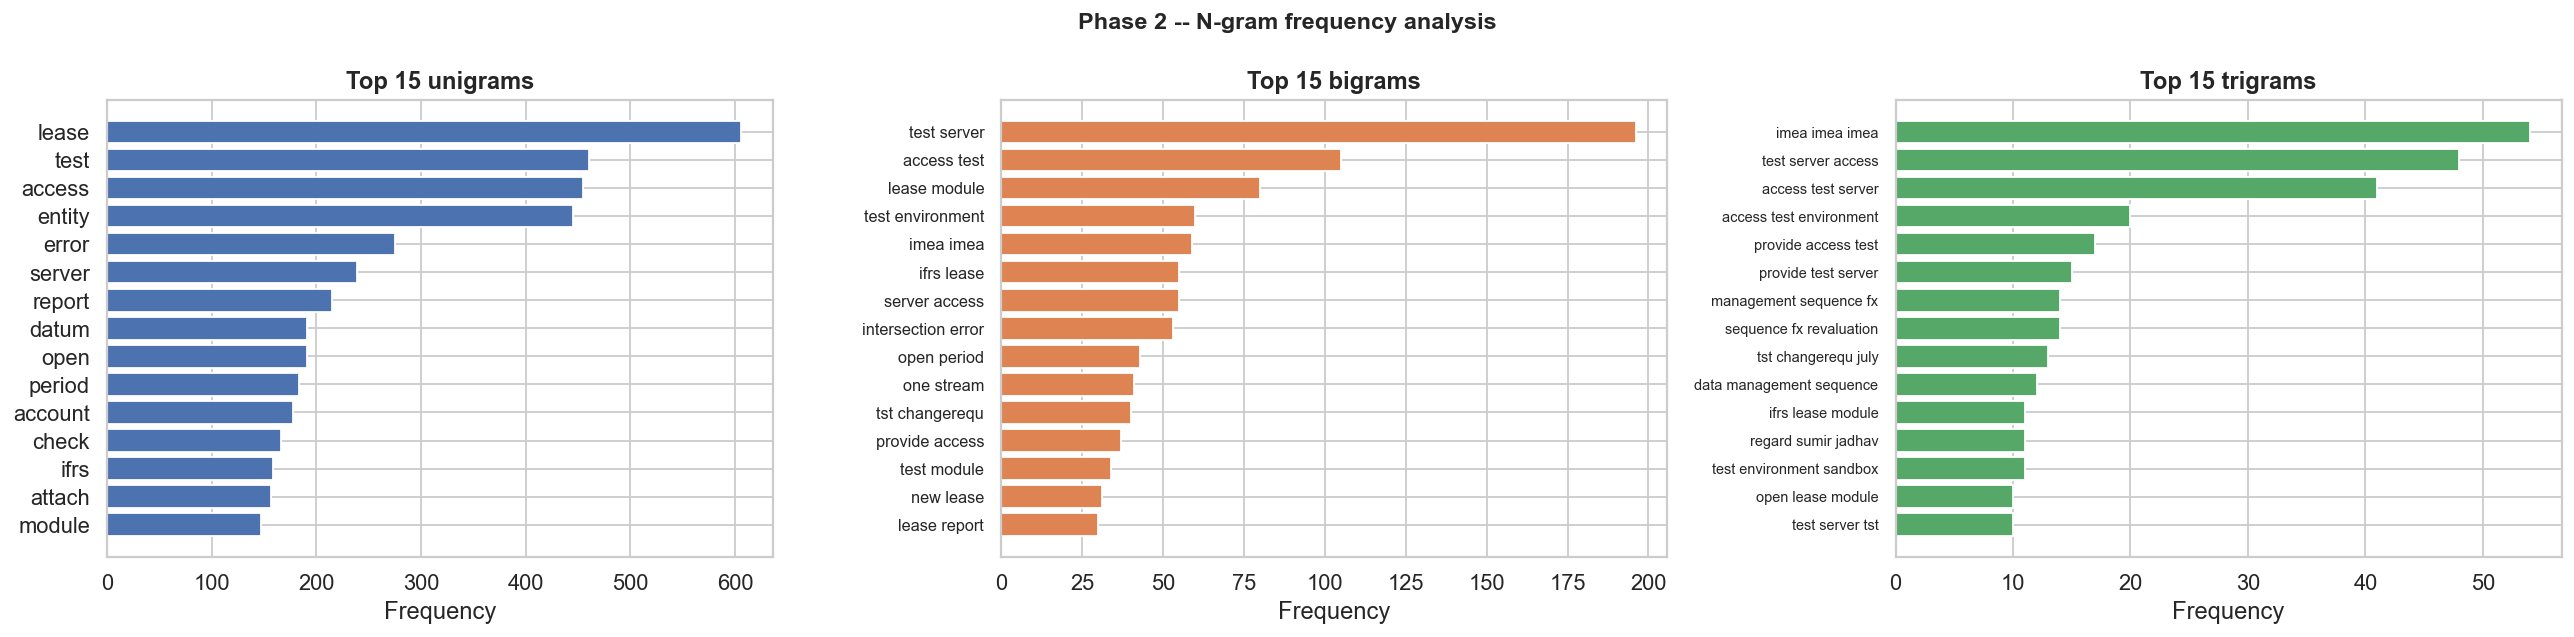

INSIGHT: Frequent bigrams/trigrams that are domain-specific --> add to Dify class descriptions.
Saved: fig_02a_ngrams.png


In [52]:
# Visual 2A: N-gram bar charts (unigrams, bigrams, trigrams)
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].barh(top_uni['word'][:15][::-1], top_uni['count'][:15][::-1],
             color=BRAND_COLORS[0], edgecolor='white')
axes[0].set_xlabel('Frequency')
axes[0].set_title('Top 15 unigrams', fontweight='bold')

axes[1].barh(top_bigrams['bigram'][:15][::-1], top_bigrams['count'][:15][::-1],
             color=BRAND_COLORS[1], edgecolor='white')
axes[1].set_xlabel('Frequency')
axes[1].set_title('Top 15 bigrams', fontweight='bold')
axes[1].tick_params(axis='y', labelsize=9)

axes[2].barh(top_trigrams['trigram'][:15][::-1], top_trigrams['count'][:15][::-1],
             color=BRAND_COLORS[2], edgecolor='white')
axes[2].set_xlabel('Frequency')
axes[2].set_title('Top 15 trigrams', fontweight='bold')
axes[2].tick_params(axis='y', labelsize=8)

plt.suptitle('Phase 2 -- N-gram frequency analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_02a_ngrams.png', bbox_inches='tight')
plt.show()
print('INSIGHT: Frequent bigrams/trigrams that are domain-specific --> add to Dify class descriptions.')
print('Saved: fig_02a_ngrams.png')

In [19]:
# 2B: Named Entity Recognition (spaCy)
# Purpose : extract product names, module names, error codes, version numbers.
#           These become entity slots in the Dify chatbot.
# NOTE    : NER runs on RAW text -- cleaning removes casing that spaCy needs.
# Ref     : Lab 02, 03

ENTITY_TYPES = {'ORG', 'PRODUCT', 'CARDINAL', 'DATE', 'GPE', 'EVENT'}

def extract_entities(text: str):
    doc = nlp(str(text)[:1000])
    return [(ent.text.strip(), ent.label_)
            for ent in doc.ents if ent.label_ in ENTITY_TYPES]

print('Running NER on raw ticket text...')
df['entities'] = df[TEXT_COL].apply(extract_entities)
all_entities   = [(e, l) for row in df['entities'] for e, l in row]
ent_df         = pd.DataFrame(all_entities, columns=['entity', 'label'])

print(f'Total entity mentions : {len(ent_df):,}')
print('Entity type distribution:')
print(ent_df['label'].value_counts().to_string())
print('\nTop 15 most frequent entities:')
print(ent_df['entity'].str.lower().value_counts().head(15).to_string())
print('\nDify action: Frequent PRODUCT/ORG entities --> add as variable slots')
print('  in Dify workflow, e.g. {{module}}, {{error_code}}')

Running NER on raw ticket text...
Total entity mentions : 2,590
Entity type distribution:
label
ORG         1297
DATE         606
CARDINAL     374
GPE          190
PRODUCT      120
EVENT          3

Top 15 most frequent entities:
entity
onestream     77
one           65
imea          64
sandbox       47
ifrs          47
regards       37
sap           26
198           22
monthly       21
s4            20
last month    18
2023          18
2             16
group         15
ifs           14

Dify action: Frequent PRODUCT/ORG entities --> add as variable slots
  in Dify workflow, e.g. {{module}}, {{error_code}}


View positive tickets, see view

In [20]:
# 2C: POS tagging -- query structure analysis
# Purpose : understand whether users ask questions (WH-words) or describe problems.
# High WH proportion --> FAQ-style answers; High NN proportion --> routing.
# Ref     : Lecture 2; Lab 02

sample_idx = df.index[:min(200, len(df))]
all_pos    = []
for text in df.loc[sample_idx, TEXT_COL]:
    tokens = word_tokenize(str(text).lower()[:300])
    tagged = pos_tag(tokens)
    all_pos.extend([tag for _, tag in tagged])

pos_fd = FreqDist(all_pos)
pos_df = pd.DataFrame(pos_fd.most_common(15), columns=['POS_tag', 'count'])
wh_count  = sum(pos_fd[t] for t in ['WP', 'WRB', 'WDT', 'WP$'])
total_pos = sum(pos_fd.values())
print(f'Question-word (WH) proportion: {wh_count/total_pos:.1%}')
print('\nTop 15 POS tags:')
print(pos_df.to_string(index=False))
print('\nDify action: WH% > 20% --> ensure KB articles answer HOW/WHAT/WHY.')

Question-word (WH) proportion: 0.6%

Top 15 POS tags:
POS_tag  count
     NN   1351
     IN    482
     JJ    319
     VB    265
     DT    182
      .    156
    NNS    150
     TO    141
      ,    129
     RB    127
    PRP    104
     CC    103
    VBG    103
     CD     95
    VBN     90

Dify action: WH% > 20% --> ensure KB articles answer HOW/WHAT/WHY.


In [21]:
# 2D: VADER sentiment -- escalation routing
# Purpose : flag frustrated/urgent tickets before intent classification.
# VADER runs on raw text -- negation and punctuation matter for accuracy.
# Ref     : Hutto & Gilbert (2014); Lecture 5; MA2 Part 1

vader = SentimentIntensityAnalyzer()

print('Running VADER on all tickets...')
vader_scores         = df[TEXT_COL].apply(lambda t: vader.polarity_scores(str(t)))
df['vader_compound'] = vader_scores.apply(lambda x: x['compound'])
df['vader_neg']      = vader_scores.apply(lambda x: x['neg'])

# Escalation threshold: -0.50 (stricter than Hutto & Gilbert's +/-0.05 boundary)
# Rationale: we want to escalate only strongly negative tickets to reduce
# false positives in a B2B enterprise support context.
ESCALATION_THRESHOLD = -0.50
df['escalate_flag']  = df['vader_compound'] < ESCALATION_THRESHOLD

print('Sentiment distribution:')
bins = pd.cut(df['vader_compound'],
              bins=[-1.01, -0.50, -0.05, 0.05, 1.01],
              labels=['Strongly Negative (escalate)', 'Negative',
                      'Neutral', 'Positive'])
print(bins.value_counts().to_string())
print(f'\nEscalation candidates: {df["escalate_flag"].sum():,}'
      f' ({df["escalate_flag"].mean():.1%})')
print('\nDify action: Add an IF/ELSE node BEFORE the QUESTION CLASSIFIER.')
print('  Route sentiment < -0.5 to a human-agent handoff node immediately.')

Running VADER on all tickets...
Sentiment distribution:
vader_compound
Positive                        826
Neutral                         693
Negative                        258
Strongly Negative (escalate)     49

Escalation candidates: 48 (2.6%)

Dify action: Add an IF/ELSE node BEFORE the QUESTION CLASSIFIER.
  Route sentiment < -0.5 to a human-agent handoff node immediately.


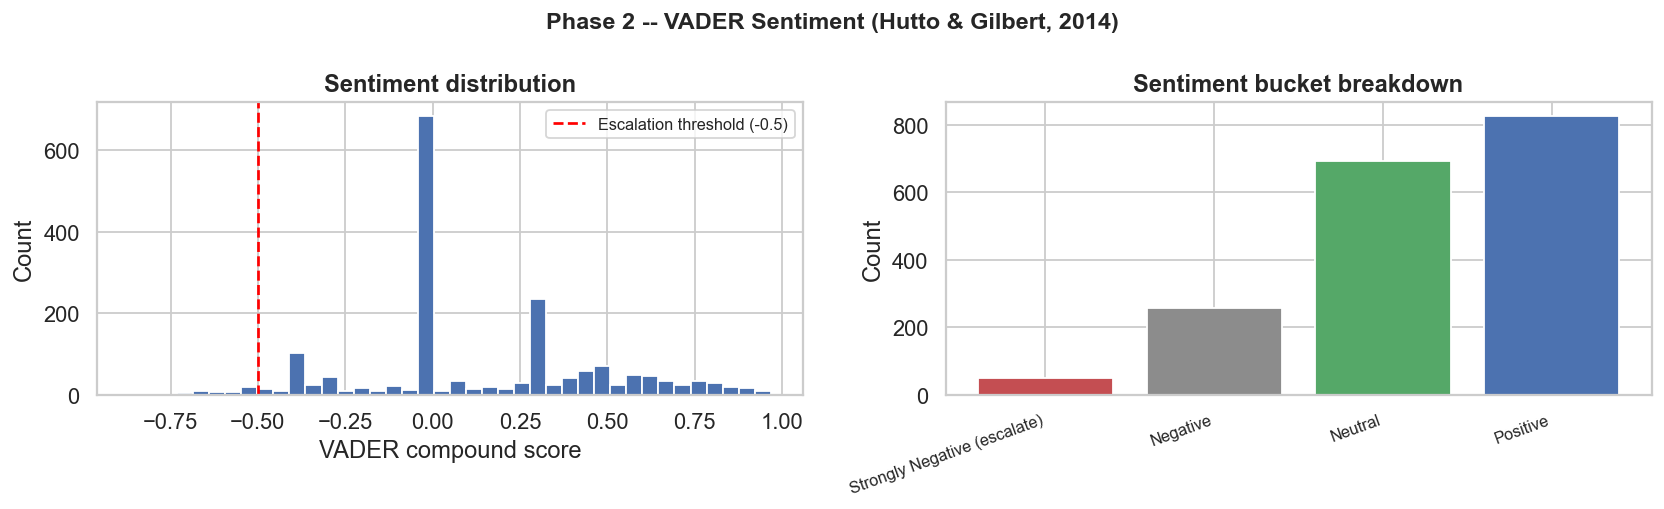

Saved: fig_02d_vader.png


In [22]:
# Visual 2D: VADER distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['vader_compound'], bins=40,
             color=BRAND_COLORS[0], edgecolor='white')
axes[0].axvline(ESCALATION_THRESHOLD, color='red', linestyle='--',
                linewidth=1.5,
                label=f'Escalation threshold ({ESCALATION_THRESHOLD})')
axes[0].set_xlabel('VADER compound score')
axes[0].set_ylabel('Count')
axes[0].set_title('Sentiment distribution', fontweight='bold')
axes[0].legend(fontsize=9)

sent_vc = bins.value_counts(sort=False)
axes[1].bar(range(len(sent_vc)), sent_vc.values,
            color=[BRAND_COLORS[3], BRAND_COLORS[7],
                   BRAND_COLORS[2], BRAND_COLORS[0]],
            edgecolor='white')
axes[1].set_xticks(range(len(sent_vc)))
axes[1].set_xticklabels(sent_vc.index, rotation=20, ha='right', fontsize=9)
axes[1].set_ylabel('Count')
axes[1].set_title('Sentiment bucket breakdown', fontweight='bold')

plt.suptitle('Phase 2 -- VADER Sentiment (Hutto & Gilbert, 2014)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_02d_vader.png', bbox_inches='tight')
plt.show()
print('Saved: fig_02d_vader.png')

---
## Phase 3 -- LDA Topic Discovery

**Goal:** Discover the latent intent clusters in the ticket corpus WITHOUT
using any labels. Each LDA topic = a candidate Dify QUESTION CLASSIFIER class.

**This is the primary analysis of the pipeline.**

**Techniques:**
- LDA (Blei et al., 2003) via Gensim -- Lecture 7, Lab 07
- Coherence score c_v to select optimal K -- Lab 07 extension
- pyLDAvis interactive visualisation -- Lab 07

> Blei et al. (2003): LDA treats each document as a mixture of topics
> and each topic as a distribution over words.

In [23]:
# 3A: Build Gensim Dictionary + Bag-of-Words corpus
# Input : list of token lists (df['tokens'])
# Output: gensim Dictionary + BoW corpus
# Ref   : Lab 07 -- gensim.corpora.Dictionary, filter_extremes, doc2bow

tokenized  = df['tokens'].tolist()
dictionary = corpora.Dictionary(tokenized)
print(f'Dictionary before filtering: {len(dictionary):,} unique tokens')

# filter_extremes removes:
#   no_below=5  : tokens in fewer than 5 docs (too rare, unreliable signal)
#   no_above=0.5: tokens in > 50% of docs (ubiquitous, like stopwords)
# Ref: Lab 07
dictionary.filter_extremes(no_below=5, no_above=0.50, keep_n=50_000)
print(f'Dictionary after filtering : {len(dictionary):,} unique tokens')

bow_corpus = [dictionary.doc2bow(doc) for doc in tokenized]
print(f'BoW corpus                 : {len(bow_corpus):,} documents')

if len(dictionary) < 50:
    print('WARNING: Dictionary has fewer than 50 tokens after filtering.')
    print('  Reduce no_below to 2 or review DOMAIN_STOPWORDS.')

Dictionary before filtering: 2,095 unique tokens
Dictionary after filtering : 507 unique tokens
BoW corpus                 : 1,826 documents


In [24]:
# 3B: Coherence sweep to find optimal number of topics
# We train LDA for K = 2 to 15 and compute c_v coherence for each K.
# c_v measures how often top words co-occur in a sliding window.
# Higher coherence = more interpretable, semantically coherent topics.
# Ref: Blei et al. (2003); Lab 07 extension exercise

# ====================================================================
# OPTIONAL EDIT: adjust range for your dataset size
# For < 300 tickets use range(2, 9)
# For > 1000 tickets use range(2, 18)
# ====================================================================
TOPIC_RANGE = range(2, 14)
PASSES      = 10
# ====================================================================

coherence_scores = []
print('Running coherence sweep -- may take several minutes...')
for k in TOPIC_RANGE:
    lda_tmp = gensim.models.LdaModel(
        corpus=bow_corpus, id2word=dictionary,
        num_topics=k, random_state=42,
        passes=PASSES, alpha='auto', eta='auto'
    )
    score = CoherenceModel(
        model=lda_tmp, texts=tokenized,
        dictionary=dictionary, coherence='c_v'
    ).get_coherence()
    coherence_scores.append(score)
    print(f'  k={k:2d}   coherence(c_v) = {score:.4f}')

best_k = list(TOPIC_RANGE)[int(np.argmax(coherence_scores))]
print(f'\nRecommended topics: {best_k}  (coherence = {max(coherence_scores):.4f})')
print('Tip: If the curve is flat, prefer the smallest k where topics are')
print('  clearly distinct in the word clouds below.')

Running coherence sweep -- may take several minutes...
  k= 2   coherence(c_v) = 0.3036
  k= 3   coherence(c_v) = 0.2876
  k= 4   coherence(c_v) = 0.3565
  k= 5   coherence(c_v) = 0.3739
  k= 6   coherence(c_v) = 0.3480
  k= 7   coherence(c_v) = 0.3314
  k= 8   coherence(c_v) = 0.3355
  k= 9   coherence(c_v) = 0.3514
  k=10   coherence(c_v) = 0.3497
  k=11   coherence(c_v) = 0.3302
  k=12   coherence(c_v) = 0.3957
  k=13   coherence(c_v) = 0.3290

Recommended topics: 12  (coherence = 0.3957)
Tip: If the curve is flat, prefer the smallest k where topics are
  clearly distinct in the word clouds below.


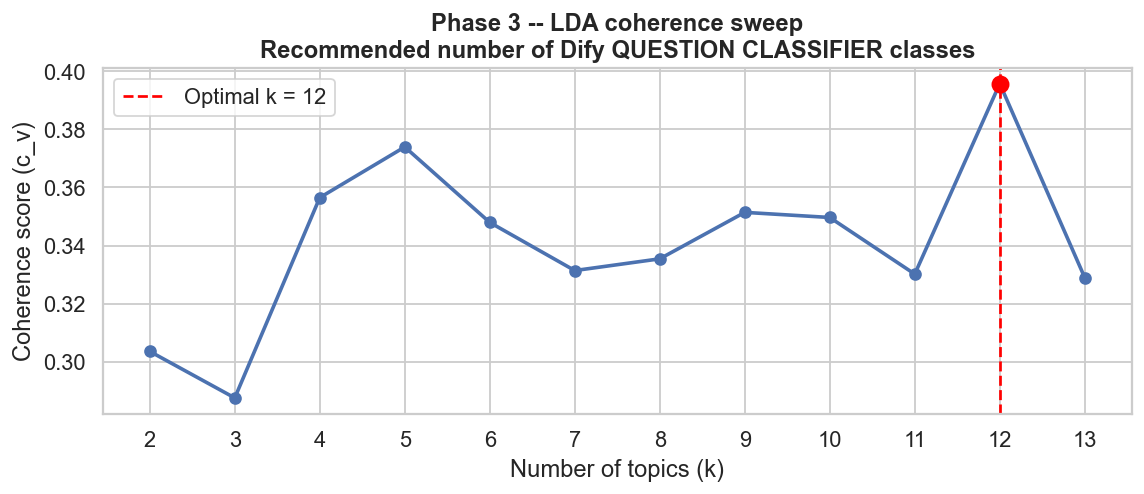

Dify action: Update QUESTION CLASSIFIER to 12 classes.
Saved: fig_03a_coherence.png


In [25]:
# Visual 3A: Coherence curve
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(TOPIC_RANGE), coherence_scores, marker='o',
        color=BRAND_COLORS[0], linewidth=2, markersize=6)
ax.axvline(best_k, color='red', linestyle='--', linewidth=1.5,
           label=f'Optimal k = {best_k}')
ax.scatter([best_k], [max(coherence_scores)], color='red', zorder=5, s=80)
ax.set_xlabel('Number of topics (k)')
ax.set_ylabel('Coherence score (c_v)')
ax.set_title('Phase 3 -- LDA coherence sweep\n'
             'Recommended number of Dify QUESTION CLASSIFIER classes',
             fontweight='bold')
ax.legend()
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.tight_layout()
plt.savefig('fig_03a_coherence.png', bbox_inches='tight')
plt.show()
print(f'Dify action: Update QUESTION CLASSIFIER to {best_k} classes.')
print('Saved: fig_03a_coherence.png')

In [26]:
# 3C: Train final LDA model with best_k
# 20 passes for a stable, production-quality model.
# Ref: Lab 07; Blei et al. (2003)

lda_model = gensim.models.LdaModel(
    corpus=bow_corpus, id2word=dictionary,
    num_topics=best_k, random_state=42,
    passes=20, alpha='auto', eta='auto'
)

print(f'LDA model trained with {best_k} topics.\n')
print('Top words per topic (candidate Dify class keywords):')
print('='*70)

topic_data = []
for idx, topic in lda_model.print_topics(-1):
    kws = [kw.strip().split('*')[1].strip().strip('"')
           for kw in topic.split('+')]
    topic_data.append({'topic_id': idx, 'keywords': kws})
    print(f'Topic {idx:2d}: {"  |  ".join(kws[:8])}')
print('='*70)

# Assign dominant topic and confidence to each ticket
def get_dominant_topic(bow_doc):
    topics = lda_model.get_document_topics(bow_doc, minimum_probability=0)
    return max(topics, key=lambda x: x[1])[0] if topics else -1

def get_topic_confidence(bow_doc):
    topics = lda_model.get_document_topics(bow_doc, minimum_probability=0)
    return max(topics, key=lambda x: x[1])[1] if topics else 0.0

df['lda_topic']      = [get_dominant_topic(b)   for b in bow_corpus]
df['lda_confidence'] = [get_topic_confidence(b) for b in bow_corpus]

print('\nTicket volume per LDA topic:')
for tid, vol in df['lda_topic'].value_counts().sort_index().items():
    print(f'  Topic {tid:2d}: {vol:5,} tickets ({vol/len(df)*100:.1f}%)')

print(f'\nMedian LDA confidence: {df["lda_confidence"].median():.3f}')
print('Low median (< 0.35) = topics overlap --> reduce k.')

LDA model trained with 12 topics.

Top words per topic (candidate Dify class keywords):
Topic  0: account  |  new  |  lease  |  see  |  value  |  input  |  number  |  change
Topic  1: entity  |  account  |  form  |  amount  |  close  |  check  |  report  |  activity
Topic  2: open  |  period  |  test  |  entity  |  sandbox  |  module  |  environment  |  jan
Topic  3: lease  |  ifrs  |  module  |  imea  |  early  |  calculate  |  payment  |  contract
Topic  4: access  |  test  |  server  |  provide  |  entity  |  production  |  login  |  enable
Topic  5: balance  |  asset  |  account  |  match  |  update  |  opening  |  file  |  still
Topic  6: test  |  access  |  tst  |  changerequ  |  workflow  |  june  |  testing  |  environment
Topic  7: error  |  entity  |  validation  |  attach  |  datum  |  intersection  |  report  |  access
Topic  8: lease  |  scenario  |  rofoq  |  actual  |  cube  |  entity  |  rofo  |  number
Topic  9: excel  |  one  |  add  |  stream  |  report  |  file  |  

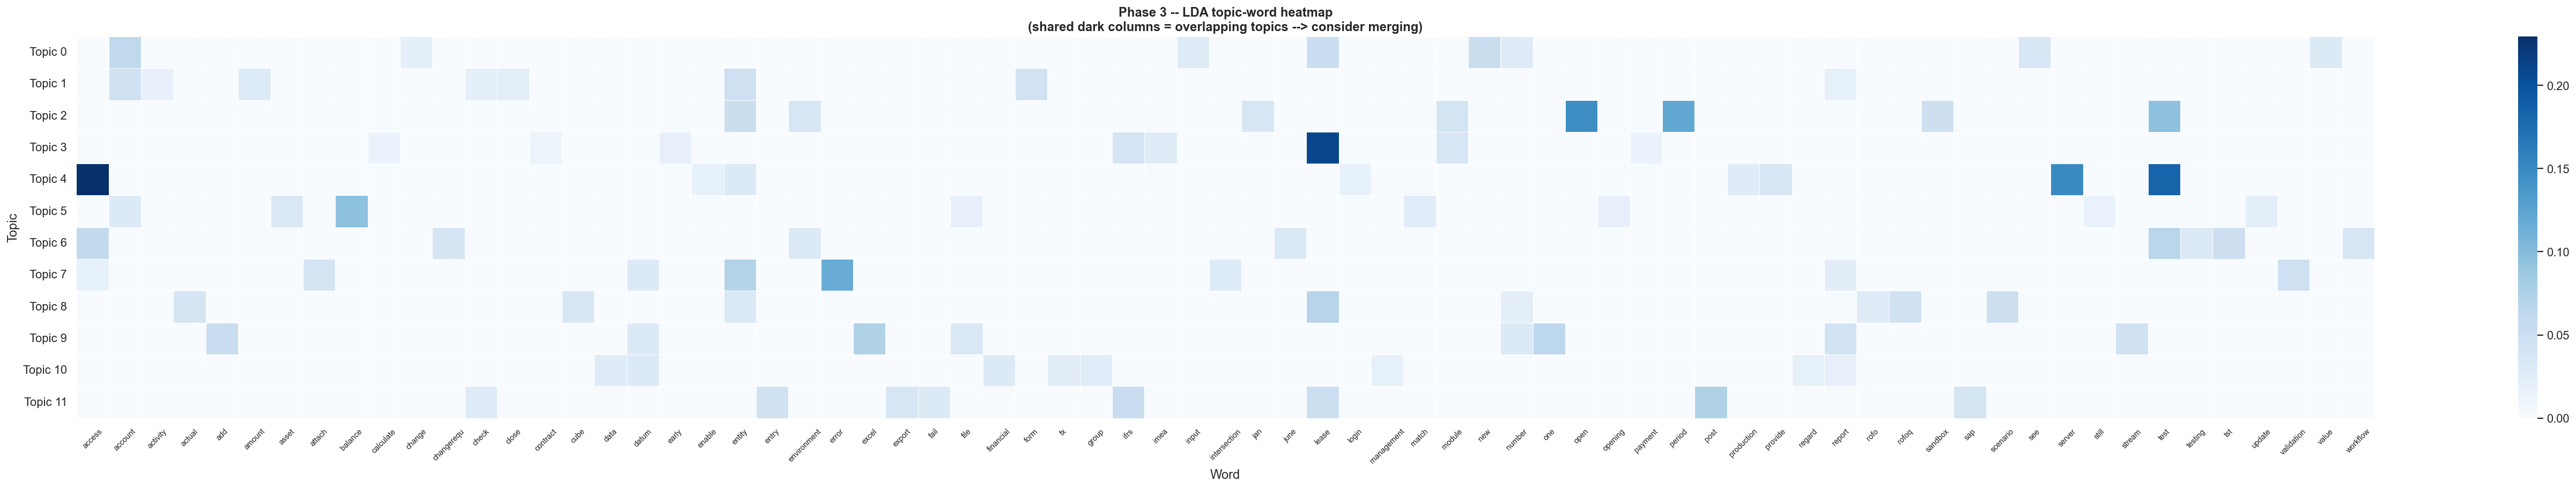

Saved: fig_03b_topic_heatmap.png


In [27]:
# Visual 3B: Topic word-weight heatmap
TOP_WORDS_VIZ = 8
topic_matrix  = []
word_labels   = set()
for t in range(best_k):
    top_words = lda_model.show_topic(t, topn=TOP_WORDS_VIZ)
    for word, _ in top_words:
        word_labels.add(word)
    topic_matrix.append(dict(top_words))

word_labels = sorted(word_labels)
heat_data   = np.array([[row.get(w, 0.0) for w in word_labels]
                         for row in topic_matrix])

fig, ax = plt.subplots(figsize=(max(12, len(word_labels) * 0.6),
                                 max(4, best_k * 0.6)))
sns.heatmap(heat_data, xticklabels=word_labels,
            yticklabels=[f'Topic {i}' for i in range(best_k)],
            cmap='Blues', ax=ax, linewidths=0.3)
ax.set_xlabel('Word')
ax.set_ylabel('Topic')
ax.set_title('Phase 3 -- LDA topic-word heatmap\n'
             '(shared dark columns = overlapping topics --> consider merging)',
             fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=8)
plt.tight_layout()
plt.savefig('fig_03b_topic_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved: fig_03b_topic_heatmap.png')

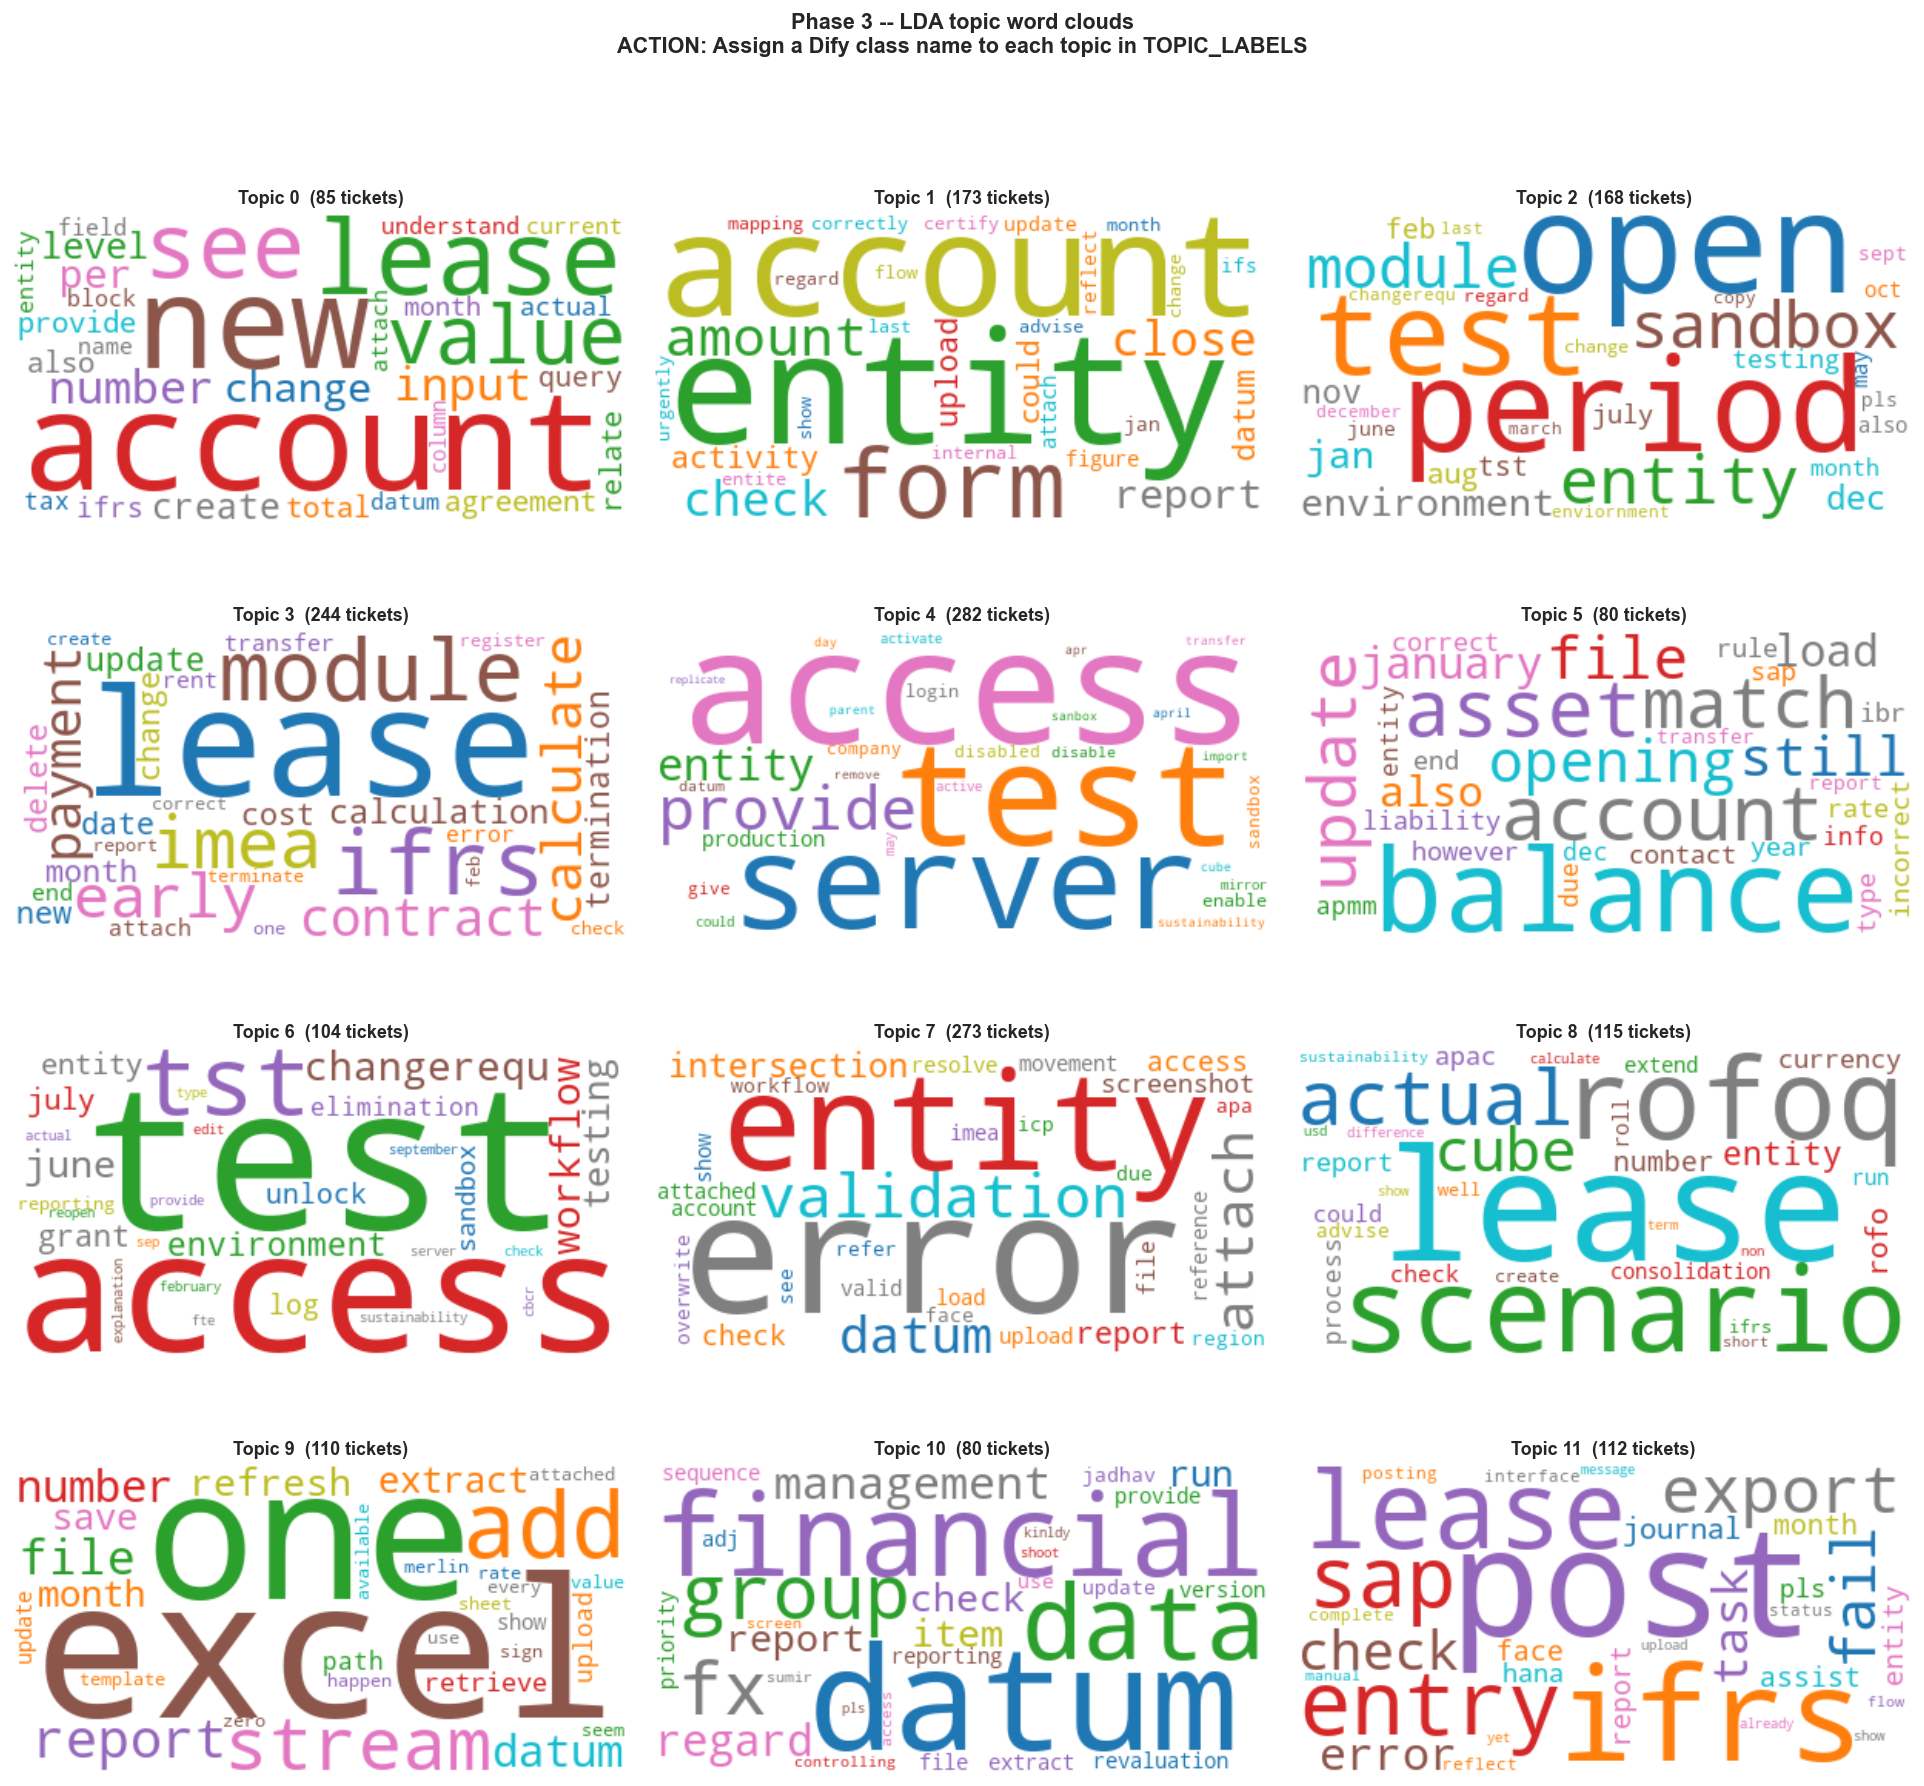

Saved: fig_03c_topic_wordclouds.png


In [28]:
# Visual 3C: Word cloud per topic
# ACTION: After running this cell, assign a Dify class name to each topic
# in the TOPIC_LABELS dict in the next cell.

cols  = min(3, best_k)
rows  = (best_k + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 3.5))
axes  = np.array(axes).flatten()

for t_idx in range(best_k):
    top_words = dict(lda_model.show_topic(t_idx, topn=30))
    vol       = (df['lda_topic'] == t_idx).sum()
    wc_topic  = WordCloud(width=400, height=200,
                          background_color='white',
                          colormap='tab10'
                          ).generate_from_frequencies(top_words)
    axes[t_idx].imshow(wc_topic, interpolation='bilinear')
    axes[t_idx].axis('off')
    axes[t_idx].set_title(f'Topic {t_idx}  ({vol} tickets)',
                           fontweight='bold', fontsize=10)

for j in range(best_k, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Phase 3 -- LDA topic word clouds\n'
             'ACTION: Assign a Dify class name to each topic in TOPIC_LABELS',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_03c_topic_wordclouds.png', bbox_inches='tight')
plt.show()
print('Saved: fig_03c_topic_wordclouds.png')

In [29]:
# Interactive pyLDAvis
# Overlapping bubbles --> merge those topics.
# Well-separated bubbles --> keep as distinct Dify classes.
# Ref: Lab 07

try:
    import pyLDAvis
    import pyLDAvis.gensim_models
    pyLDAvis.enable_notebook()
    vis = pyLDAvis.gensim_models.prepare(lda_model, bow_corpus, dictionary)
    print('Interactive LDA visualisation loaded.')
    print('Overlapping bubbles --> merge in Dify QUESTION CLASSIFIER.')
    pyLDAvis.display(vis)
except Exception as e:
    print(f'pyLDAvis not available: {e}')

Interactive LDA visualisation loaded.
Overlapping bubbles --> merge in Dify QUESTION CLASSIFIER.


---
## Phase 3 Checkpoint -- Label Your Topics

**Stop here and look at the word clouds before running Phase 4.**

Assign a human-readable Dify class name to each topic. These names become
the intent labels in your QUESTION CLASSIFIER.

If two word clouds look very similar, assign them the same label -- they
will be merged automatically.

In [30]:
# ====================================================================
# EDIT HERE: assign a Dify class name to each topic ID
# Keys must cover every ID from 0 to best_k-1
# Example names from the OneStream domain:
#   'SYSTEM', 'TREASURY', 'TAX', 'FPA', 'ACCESS', 'REPORTING', 'OTHER'
# ====================================================================
TOPIC_LABELS = {
    0: 'TOPIC_0',   # <- replace with your label after viewing word clouds
    1: 'TOPIC_1',
    2: 'TOPIC_2',
    3: 'TOPIC_3',
    4: 'TOPIC_4',
    # Add or remove entries to match best_k
}
# ====================================================================

df['intent_label'] = df['lda_topic'].map(TOPIC_LABELS).fillna('UNKNOWN')

print('Intent label distribution after labelling:')
print(df['intent_label'].value_counts().to_string())

unknown_count = (df['intent_label'] == 'UNKNOWN').sum()
if unknown_count > 0:
    print(f'\nWARNING: {unknown_count} tickets labelled UNKNOWN.')
    print('  Check TOPIC_LABELS covers all IDs from 0 to best_k-1.')

Intent label distribution after labelling:
intent_label
UNKNOWN    874
TOPIC_4    282
TOPIC_3    244
TOPIC_1    173
TOPIC_2    168
TOPIC_0     85

  Check TOPIC_LABELS covers all IDs from 0 to best_k-1.


---
## Phase 4 -- Keyword Extraction (TF-IDF + Logistic Regression on LDA Labels)

**Goal:** Use LDA topic assignments as pseudo-labels to train a supervised
classifier. The Logistic Regression coefficient matrix identifies the
statistically most discriminative keywords per class.

**Why supervised after unsupervised?**
LDA ranks words by probability within a topic. LR coefficients rank words
by discriminative power -- how much a word separates one class FROM others.
Discriminative power is exactly what a classifier keyword list needs.

**Techniques:**
- TF-IDF (Lecture 1 bonus; Lab 06; MA2)
- Multinomial Naive Bayes baseline (Lectures 3-4; Lab 05)
- Logistic Regression with coefficient analysis (Lecture 5; MA2; Greenwashing notebook)

> Manning & Schütze (2003): discriminative classifiers learn decision
> boundaries -- they find the words that best SEPARATE classes, not
> just the words most frequent within a class.

In [31]:
# 4A: Train/test split on LDA pseudo-labels
# stratify=y preserves class proportions (as in MA2 notebook)
# Ref: MA2 -- train_test_split with stratify

X = df['clean_text']
y = df['intent_label']

# Exclude UNKNOWN labels
mask = y != 'UNKNOWN'
X, y = X[mask], y[mask]

min_class_size = y.value_counts().min()
if min_class_size < 10:
    print(f'WARNING: Smallest class has {min_class_size} samples.')
    print('  Metrics for that class will be unreliable.')
    print('  Consider merging it with a related topic in TOPIC_LABELS.')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'Train: {len(X_train):,}   Test: {len(X_test):,}')
print('\nTrain class distribution:')
print(y_train.value_counts().to_string())

Train: 761   Test: 191

Train class distribution:
intent_label
TOPIC_4    226
TOPIC_3    195
TOPIC_1    138
TOPIC_2    134
TOPIC_0     68


In [32]:
# 4B: TF-IDF vectorisation
# ngram_range=(1,2) captures multi-word patterns like 'cash pool', 'tax provision'
# Fit on TRAIN only to prevent data leakage (MA2 note on this)
# Ref: Lecture 1 bonus -- TF-IDF formula; Manning & Schütze (2003), Ch. 15

tfidf = TfidfVectorizer(
    max_features=15_000,
    ngram_range=(1, 2),   # unigrams + bigrams
    min_df=2,             # ignore very rare n-grams
    sublinear_tf=True     # log-scaled TF (used in MA2)
)
X_train_tfidf = tfidf.fit_transform(X_train)  # learn vocab from train only
X_test_tfidf  = tfidf.transform(X_test)       # apply without re-fitting
feature_names = np.array(tfidf.get_feature_names_out())

print(f'TF-IDF vocabulary : {len(feature_names):,} features')
print(f'Train matrix      : {X_train_tfidf.shape}')
print(f'Test  matrix      : {X_test_tfidf.shape}')

TF-IDF vocabulary : 1,215 features
Train matrix      : (761, 1215)
Test  matrix      : (191, 1215)


In [33]:
# 4C: Naive Bayes baseline
# alpha=0.1: Laplace smoothing to avoid zero-probability problem
# Ref: Lectures 3-4; Lab 05; Manning & Schütze (2003), Ch. 13

nb = MultinomialNB(alpha=0.1)
nb.fit(X_train_tfidf, y_train)
nb_preds = nb.predict(X_test_tfidf)
nb_acc   = accuracy_score(y_test, nb_preds)
nb_f1    = f1_score(y_test, nb_preds, average='weighted')

print('=== Naive Bayes (Baseline) ===')
print(f'Accuracy : {nb_acc:.4f}')
print(f'F1 (weighted): {nb_f1:.4f}')
print(classification_report(y_test, nb_preds))

=== Naive Bayes (Baseline) ===
Accuracy : 0.8743
F1 (weighted): 0.8731
              precision    recall  f1-score   support

     TOPIC_0       0.92      0.71      0.80        17
     TOPIC_1       0.83      0.83      0.83        35
     TOPIC_2       0.93      0.82      0.88        34
     TOPIC_3       0.87      0.94      0.90        49
     TOPIC_4       0.87      0.93      0.90        56

    accuracy                           0.87       191
   macro avg       0.88      0.85      0.86       191
weighted avg       0.88      0.87      0.87       191



In [36]:
# 4D: Logistic Regression -- keyword extractor
# class_weight='balanced' compensates for unequal topic sizes from LDA
# multi_class='multinomial' uses softmax for K > 2 (Lecture 5 slides)
# Ref: Lecture 5; MA2; Greenwashing notebook

lr = LogisticRegression(
    max_iter=1000, C=1.0,
    class_weight='balanced',
    random_state=42, solver='lbfgs',
)
lr.fit(X_train_tfidf, y_train)
lr_preds = lr.predict(X_test_tfidf)
lr_acc   = accuracy_score(y_test, lr_preds)
lr_f1    = f1_score(y_test, lr_preds, average='weighted')

print('=== Logistic Regression (Keyword Extractor) ===')
print(f'Accuracy : {lr_acc:.4f}')
print(f'F1 (weighted): {lr_f1:.4f}')
print(classification_report(y_test, lr_preds))
print(f'\nNB={nb_acc:.3f}  LR={lr_acc:.3f}')
print('Low LR accuracy (< 0.60) = topics overlap --> reduce k in coherence sweep.')

=== Logistic Regression (Keyword Extractor) ===
Accuracy : 0.8901
F1 (weighted): 0.8898
              precision    recall  f1-score   support

     TOPIC_0       0.76      0.76      0.76        17
     TOPIC_1       0.82      0.89      0.85        35
     TOPIC_2       0.94      0.97      0.96        34
     TOPIC_3       0.89      0.96      0.92        49
     TOPIC_4       0.96      0.82      0.88        56

    accuracy                           0.89       191
   macro avg       0.87      0.88      0.88       191
weighted avg       0.89      0.89      0.89       191


NB=0.874  LR=0.890
Low LR accuracy (< 0.60) = topics overlap --> reduce k in coherence sweep.


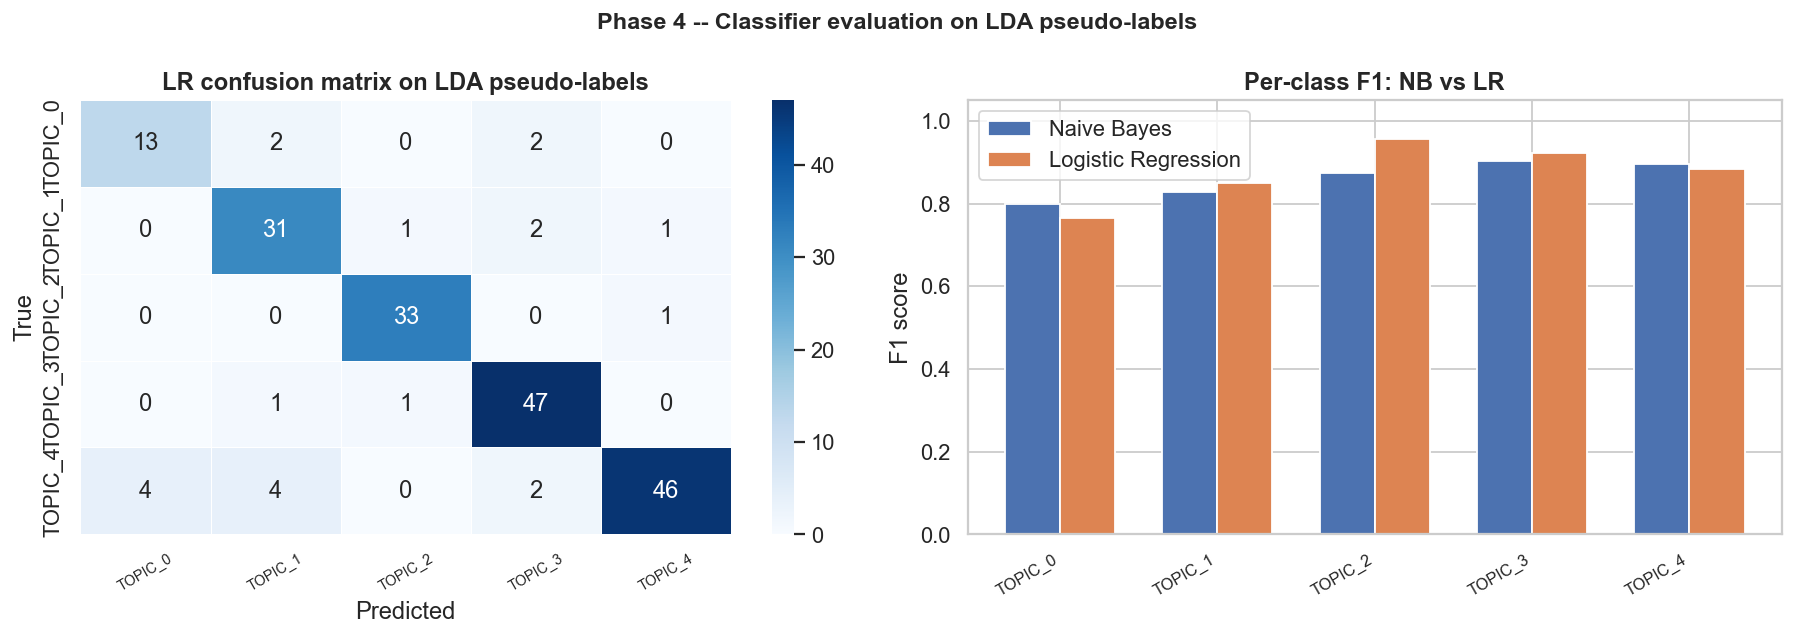

Classes with F1 < 0.50 have overlapping language --> merge in TOPIC_LABELS.
Saved: fig_04a_classifier_eval.png


In [37]:
# Visual 4A: Confusion matrix + per-class F1
classes = lr.classes_
cm = confusion_matrix(y_test, lr_preds, labels=classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            ax=axes[0], linewidths=0.5)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_title('LR confusion matrix on LDA pseudo-labels', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30, labelsize=8)

nb_f1_per = f1_score(y_test, nb_preds, average=None, labels=classes)
lr_f1_per = f1_score(y_test, lr_preds, average=None, labels=classes)
x = np.arange(len(classes))
w = 0.35
axes[1].bar(x - w/2, nb_f1_per, w, label='Naive Bayes',
             color=BRAND_COLORS[0], edgecolor='white')
axes[1].bar(x + w/2, lr_f1_per, w, label='Logistic Regression',
             color=BRAND_COLORS[1], edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(classes, rotation=30, ha='right', fontsize=9)
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel('F1 score')
axes[1].set_title('Per-class F1: NB vs LR', fontweight='bold')
axes[1].legend()

plt.suptitle('Phase 4 -- Classifier evaluation on LDA pseudo-labels',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_04a_classifier_eval.png', bbox_inches='tight')
plt.show()
print('Classes with F1 < 0.50 have overlapping language --> merge in TOPIC_LABELS.')
print('Saved: fig_04a_classifier_eval.png')

In [38]:
# 4E: Extract top discriminative keywords per class
# LR coefficient matrix shape: (n_classes, n_features)
# Largest positive coefficient per class = most discriminative keyword.
# Ref: Lecture 5 -- LR coefficients as feature importance
#      Greenwashing notebook -- per-class feature extraction

TOP_N_KEYWORDS = 20
keyword_data   = {}  # class --> list of (keyword, coefficient)

print('Top discriminative keywords per intent class (LR coefficients):')
print('='*70)

for i, cls in enumerate(classes):
    coefs   = lr.coef_[i]
    top_idx = np.argsort(coefs)[::-1][:TOP_N_KEYWORDS]
    top_kws = [(feature_names[j], round(float(coefs[j]), 4))
               for j in top_idx]
    keyword_data[cls] = top_kws
    print(f'\n{cls}:')
    for kw, coef in top_kws[:10]:
        bar = '#' * int(coef * 20)
        print(f'  {kw:30s}  coef={coef:+.4f}  {bar}')

print('='*70)
print('Higher coefficient = more discriminative = higher-priority Dify keyword.')

Top discriminative keywords per intent class (LR coefficients):

TOPIC_0:
  see                             coef=+2.1484  ##########################################
  input                           coef=+2.1431  ##########################################
  account                         coef=+1.8836  #####################################
  block                           coef=+1.8153  ####################################
  new                             coef=+1.7316  ##################################
  value                           coef=+1.7019  ##################################
  new lease                       coef=+1.5099  ##############################
  number                          coef=+1.5050  ##############################
  relate                          coef=+1.3229  ##########################
  segment                         coef=+1.2383  ########################

TOPIC_1:
  form                            coef=+1.8630  #####################################
  act

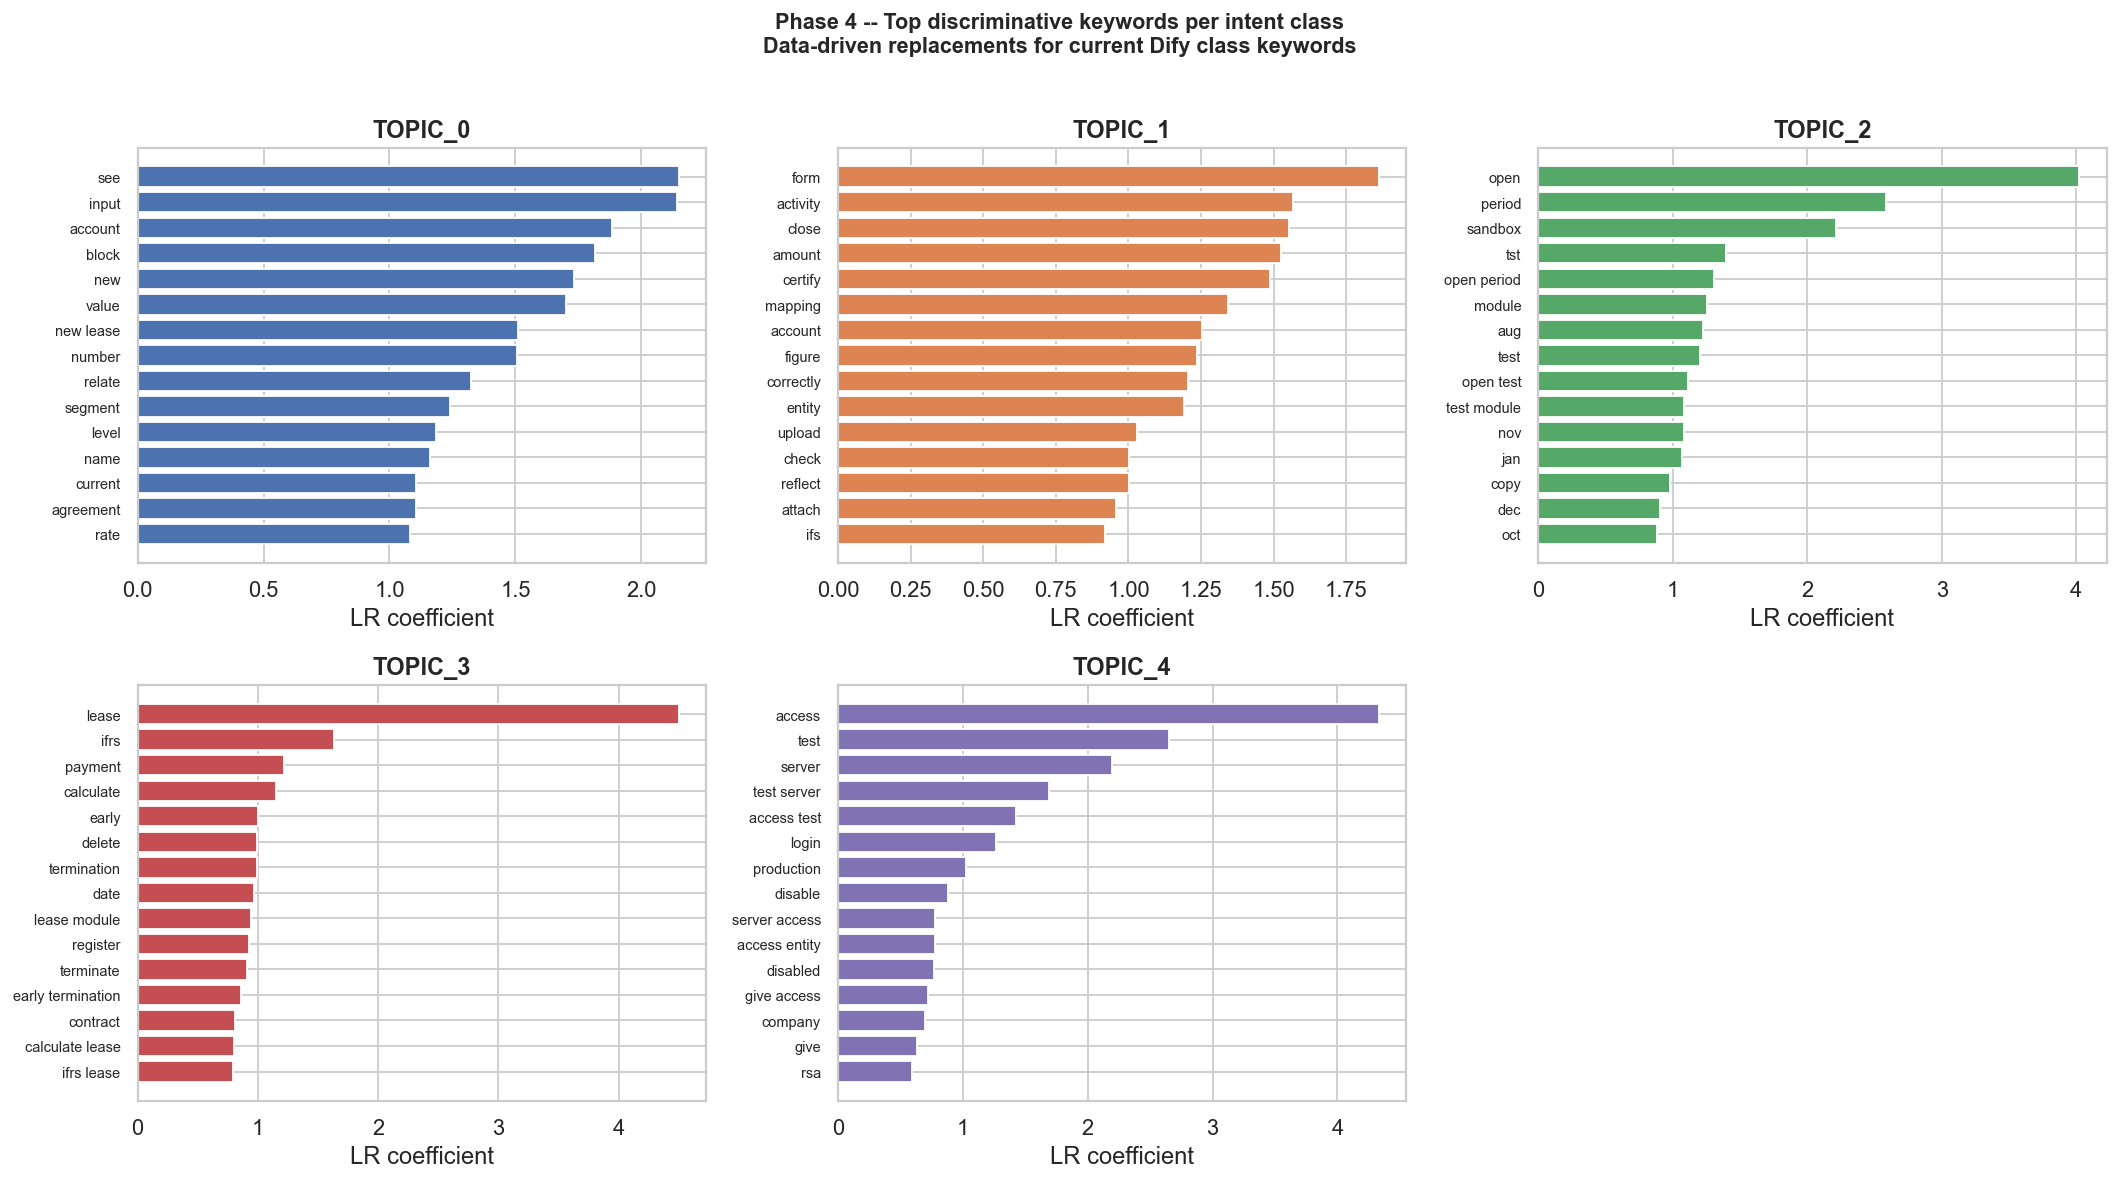

Saved: fig_04b_keywords.png


In [39]:
# Visual 4B: Keyword importance bar charts
n_cls = len(classes)
cols  = min(3, n_cls)
rows  = (n_cls + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 5.5, rows * 4.5))
axes = np.array(axes).flatten()

for i, cls in enumerate(classes):
    top_kws = keyword_data[cls][:15]
    words   = [k for k, _ in top_kws]
    coefs   = [c for _, c in top_kws]
    axes[i].barh(words[::-1], coefs[::-1],
                  color=BRAND_COLORS[i % len(BRAND_COLORS)],
                  edgecolor='white')
    axes[i].set_xlabel('LR coefficient')
    axes[i].set_title(cls, fontweight='bold')
    axes[i].tick_params(axis='y', labelsize=8)

for j in range(n_cls, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Phase 4 -- Top discriminative keywords per intent class\n'
             'Data-driven replacements for current Dify class keywords',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_04b_keywords.png', bbox_inches='tight')
plt.show()
print('Saved: fig_04b_keywords.png')

---
## Phase 5 -- Semantic Keyword Expansion (word2vec)

**Goal:** Expand each intent's keyword list with semantically similar
paraphrase variants that users may type instead of the canonical keywords.

**The problem this solves for Dify:** A user who writes 'cannot sign in'
will not match a keyword list containing only 'login'. word2vec finds
that 'authenticate', 'credential', 'access' are near-neighbours in the
ticket embedding space, so we add them to the class description.

**Techniques:**
- word2vec skip-gram -- Lecture 6-7 (vector semantics)
- Cosine similarity -- Lecture 7

In [40]:
# 5A: Train word2vec on ticket corpus
# Ref: Lecture 6-7; Lab 07 -- gensim Word2Vec

w2v = Word2Vec(
    sentences=tokenized,
    vector_size=100,   # 100-dimensional embeddings
    window=5,          # context window of +/- 5 words
    min_count=2,
    workers=4, seed=42, epochs=10
)
w2v.save('w2v_tickets.model')
print(f'word2vec vocabulary: {len(w2v.wv):,} tokens')

print('\nSanity check:')
probe_words = ['login', 'budget', 'tax', 'cash', 'report']
for probe in probe_words:
    if probe in w2v.wv:
        similar = w2v.wv.most_similar(probe, topn=5)
        sim_str = ', '.join([f'{w}({s:.2f})' for w, s in similar])
        print(f'  {probe:12s}: {sim_str}')

word2vec vocabulary: 1,114 tokens

Sanity check:
  login       : enable(1.00), use(1.00), could(1.00), check(1.00), already(1.00)
  budget      : none(0.99), report(0.99), merger(0.99), fix(0.99), urgently(0.99)
  tax         : transfer(1.00), correct(1.00), amount(1.00), try(1.00), monthly(1.00)
  cash        : transfer(1.00), due(1.00), since(1.00), contract(1.00), flow(1.00)
  report      : level(1.00), match(1.00), currency(1.00), number(1.00), monthly(1.00)


In [41]:
# 5B: Expand keyword lists with word2vec near-neighbours
# Seed keywords = top-8 LR keywords per class.
# Near-neighbours = semantically similar paraphrase variants.
# Ref: Lecture 7 -- cosine similarity for semantic similarity

SEED_KEYWORDS  = 8
NEIGHBOURS     = 3
MIN_SIMILARITY = 0.55

expanded_keywords = {}  # class --> list of all keywords

print('Keyword expansion results:')
print('='*70)

for cls in classes:
    seeds    = [kw for kw, _ in keyword_data[cls][:SEED_KEYWORDS]
                if kw in w2v.wv]
    original = [kw for kw, _ in keyword_data[cls][:SEED_KEYWORDS]]
    new_kws  = set()
    for seed in seeds:
        for word, sim in w2v.wv.most_similar(seed, topn=NEIGHBOURS):
            if sim >= MIN_SIMILARITY and word not in original:
                new_kws.add(word)
    all_kws = original + sorted(new_kws)
    expanded_keywords[cls] = all_kws
    print(f'\n{cls}:')
    print(f'  LR seeds  : {original}')
    print(f'  w2v added : {sorted(new_kws)}')

Keyword expansion results:

TOPIC_0:
  LR seeds  : ['see', 'input', 'account', 'block', 'new', 'value', 'new lease', 'number']
  w2v added : ['attached', 'close', 'contract', 'correct', 'explanation', 'find', 'form', 'load', 'look', 'match', 'payment', 'reporting', 'seem', 'show', 'since', 'validation', 'year']

TOPIC_1:
  LR seeds  : ['form', 'activity', 'close', 'amount', 'certify', 'mapping', 'account', 'figure']
  w2v added : ['advise', 'appear', 'asset', 'assist', 'check', 'company', 'correct', 'entity', 'look', 'monthly', 'number', 'raise', 'set', 'show', 'since', 'still', 'transfer', 'validation']

TOPIC_2:
  LR seeds  : ['open', 'period', 'sandbox', 'tst', 'open period', 'module', 'aug', 'test']
  w2v added : ['also', 'environment', 'feb', 'jan', 'july', 'nov', 'server', 'testing']

TOPIC_3:
  LR seeds  : ['lease', 'ifrs', 'payment', 'calculate', 'early', 'delete', 'termination', 'date']
  w2v added : ['balance', 'calculation', 'contract', 'correct', 'create', 'due', 'however',

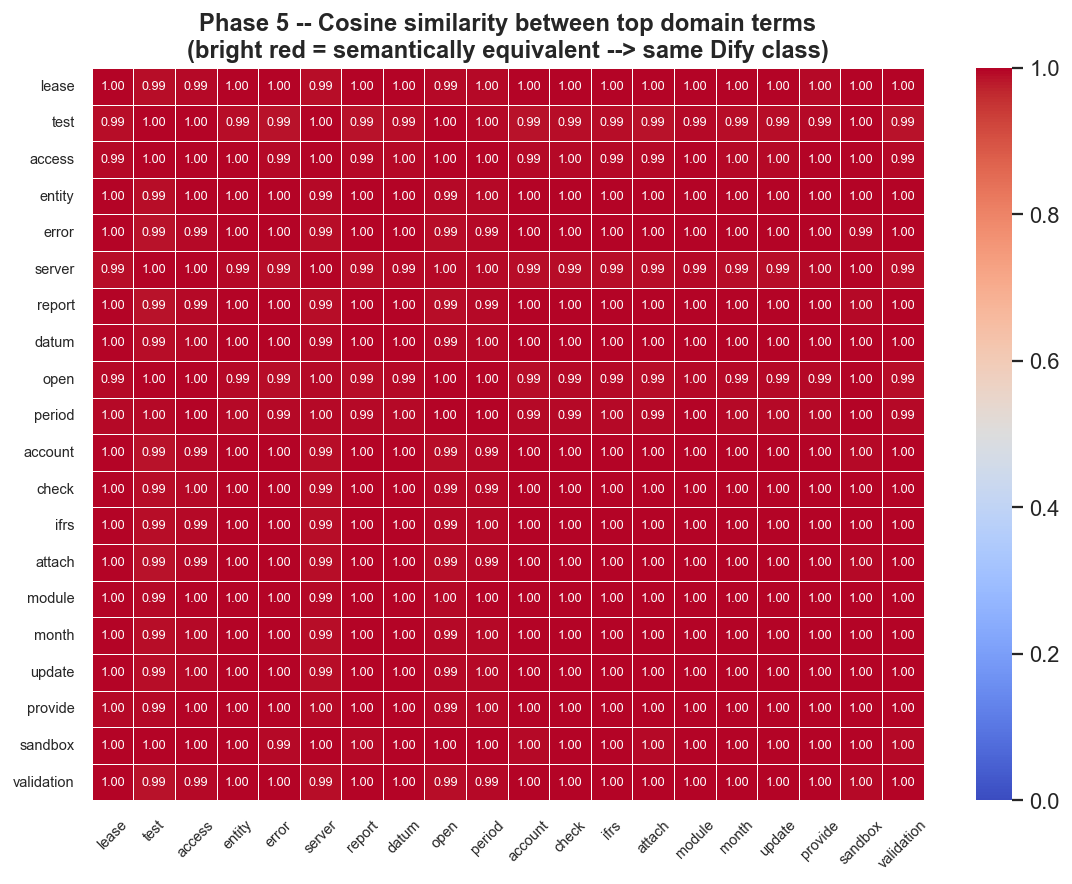

Saved: fig_05a_word_similarity.png


In [42]:
# Visual 5A: Cosine similarity heatmap between top domain terms
# Clusters of high similarity = semantically related concepts.
# Ref: Lecture 7 -- cosine similarity

top20_words = [
    w for w, _ in unigram_fd.most_common(60)
    if w in w2v.wv
][:20]

if len(top20_words) >= 5:
    vecs_20    = np.vstack([w2v.wv[w] for w in top20_words])
    sim_matrix = cosine_similarity(vecs_20)
    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(sim_matrix,
                xticklabels=top20_words, yticklabels=top20_words,
                cmap='coolwarm', center=0.5, vmin=0, vmax=1,
                ax=ax, linewidths=0.3,
                annot=True, fmt='.2f', annot_kws={'size': 7})
    ax.set_title('Phase 5 -- Cosine similarity between top domain terms\n'
                 '(bright red = semantically equivalent --> same Dify class)',
                 fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0, labelsize=8)
    plt.tight_layout()
    plt.savefig('fig_05a_word_similarity.png', bbox_inches='tight')
    plt.show()
    print('Saved: fig_05a_word_similarity.png')

---
## Phase 6 -- Dify Export and Routing Recommendations

**Goal:** Produce all outputs needed to update the Dify workflow directly.

**What Dify's QUESTION CLASSIFIER needs:**
Each class requires a name and a natural-language description. The LLM
(gpt-4.1-mini in your current flow) uses this description as context
for its routing decision -- so descriptions should be rich, specific,
and cover paraphrase variants, not just a comma-separated word list.

**Dify architecture note:**
VADER sentiment cannot run natively as a Dify node without a custom
code block. The recommendation below uses a Code node with a lightweight
keyword heuristic as a Dify-compatible approximation.

In [43]:
# 6A: Per-intent statistics

print('Intent summary:')
print('='*80)
intent_summary = []

for cls in classes:
    cls_df   = df[df['intent_label'] == cls]
    vol      = len(cls_df)
    pct      = vol / len(df) * 100
    avg_conf = cls_df['lda_confidence'].mean()
    esc_rate = cls_df['escalate_flag'].mean() * 100
    top_kws  = [kw for kw, _ in keyword_data[cls][:10]]

    intent_summary.append({
        'intent'          : cls,
        'ticket_volume'   : vol,
        'volume_pct'      : round(pct, 1),
        'avg_lda_conf'    : round(avg_conf, 3),
        'escalation_rate' : round(esc_rate, 1),
        'top_keywords'    : top_kws,
        'all_keywords'    : expanded_keywords[cls]
    })

    print(f'{cls}  ({vol} tickets, {pct:.1f}%)')
    print(f'  LDA confidence  : {avg_conf:.3f}')
    print(f'  Escalation rate : {esc_rate:.1f}%')
    print(f'  Top keywords    : {top_kws[:8]}')
    print()

intent_df = pd.DataFrame(intent_summary)

Intent summary:
TOPIC_0  (85 tickets, 4.7%)
  LDA confidence  : 0.649
  Escalation rate : 0.0%
  Top keywords    : ['see', 'input', 'account', 'block', 'new', 'value', 'new lease', 'number']

TOPIC_1  (173 tickets, 9.5%)
  LDA confidence  : 0.643
  Escalation rate : 0.0%
  Top keywords    : ['form', 'activity', 'close', 'amount', 'certify', 'mapping', 'account', 'figure']

TOPIC_2  (168 tickets, 9.2%)
  LDA confidence  : 0.675
  Escalation rate : 0.6%
  Top keywords    : ['open', 'period', 'sandbox', 'tst', 'open period', 'module', 'aug', 'test']

TOPIC_3  (244 tickets, 13.4%)
  LDA confidence  : 0.676
  Escalation rate : 3.3%
  Top keywords    : ['lease', 'ifrs', 'payment', 'calculate', 'early', 'delete', 'termination', 'date']

TOPIC_4  (282 tickets, 15.4%)
  LDA confidence  : 0.666
  Escalation rate : 0.0%
  Top keywords    : ['access', 'test', 'server', 'test server', 'access test', 'login', 'production', 'disable']



In [44]:
# 6B: Generate Dify QUESTION CLASSIFIER class descriptions
# Format: natural-language description the LLM uses for routing.
# More effective than a raw keyword list because the LLM understands
# the semantic context of a descriptive sentence.

print('DIFY QUESTION CLASSIFIER -- PASTE-READY CLASS DESCRIPTIONS')
print('='*70)
print('Paste each block into the corresponding class in your Dify node.\n')

dify_descriptions = {}
for entry in intent_summary:
    cls  = entry['intent']
    kws  = entry['all_keywords'][:15]
    # Natural-language description for the Dify LLM classifier
    desc = (
        f"Questions and issues related to {cls.replace('_', ' ').lower()}. "
        f"Includes queries about: {', '.join(kws[:10])}."
        + (f" Also matches: {', '.join(kws[10:15])}." if len(kws) > 10 else '')
    )
    dify_descriptions[cls] = desc
    print(f'CLASS: {cls}')
    print(f'  DESCRIPTION: {desc}')
    print()

print('='*70)
print('FALLBACK CLASS:')
print('  Add one final class called UNCLEAR (or OTHER) with description:')
print('  "The question does not clearly match any of the above categories.')
print('   The user needs to be asked a clarifying question."')
print('  Route this class to a clarifying-question node in Dify.')

DIFY QUESTION CLASSIFIER -- PASTE-READY CLASS DESCRIPTIONS
Paste each block into the corresponding class in your Dify node.

CLASS: TOPIC_0
  DESCRIPTION: Questions and issues related to topic 0. Includes queries about: see, input, account, block, new, value, new lease, number, attached, close. Also matches: contract, correct, explanation, find, form.

CLASS: TOPIC_1
  DESCRIPTION: Questions and issues related to topic 1. Includes queries about: form, activity, close, amount, certify, mapping, account, figure, advise, appear. Also matches: asset, assist, check, company, correct.

CLASS: TOPIC_2
  DESCRIPTION: Questions and issues related to topic 2. Includes queries about: open, period, sandbox, tst, open period, module, aug, test, also, environment. Also matches: feb, jan, july, nov, server.

CLASS: TOPIC_3
  DESCRIPTION: Questions and issues related to topic 3. Includes queries about: lease, ifrs, payment, calculate, early, delete, termination, date, balance, calculation. Also matche

In [45]:
# 6C: Export Dify intent taxonomy CSV
# This is the primary deliverable. Import into your documentation or
# use as the reference sheet when updating the Dify QUESTION CLASSIFIER.

taxonomy_rows = []
for entry in intent_summary:
    cls = entry['intent']
    taxonomy_rows.append({
        'dify_class_name'    : cls,
        'dify_description'   : dify_descriptions[cls],
        'top_keywords_lr'    : ', '.join([kw for kw, _ in keyword_data[cls][:10]]),
        'expanded_keywords'  : ', '.join(entry['all_keywords'][:15]),
        'ticket_volume'      : entry['ticket_volume'],
        'volume_pct'         : entry['volume_pct'],
        'avg_lda_confidence' : entry['avg_lda_conf'],
        'escalation_rate_pct': entry['escalation_rate'],
        'notes': (
            'LOW CONFIDENCE -- consider merging'
            if entry['avg_lda_conf'] < 0.35 else
            'HIGH VOLUME -- verify KB coverage'
            if entry['volume_pct'] > 30 else
            'SMALL CLASS -- monitor recall'
            if entry['ticket_volume'] < 50 else
            'OK'
        )
    })

taxonomy_df = pd.DataFrame(taxonomy_rows)
taxonomy_df.to_csv('dify_intent_taxonomy.csv', index=False)

print('Exported: dify_intent_taxonomy.csv')
print()
print(taxonomy_df[['dify_class_name', 'ticket_volume', 'volume_pct',
                    'avg_lda_confidence', 'escalation_rate_pct',
                    'notes']].to_string(index=False))

Exported: dify_intent_taxonomy.csv

dify_class_name  ticket_volume  volume_pct  avg_lda_confidence  escalation_rate_pct notes
        TOPIC_0             85         4.7               0.649                  0.0    OK
        TOPIC_1            173         9.5               0.643                  0.0    OK
        TOPIC_2            168         9.2               0.675                  0.6    OK
        TOPIC_3            244        13.4               0.676                  3.3    OK
        TOPIC_4            282        15.4               0.666                  0.0    OK


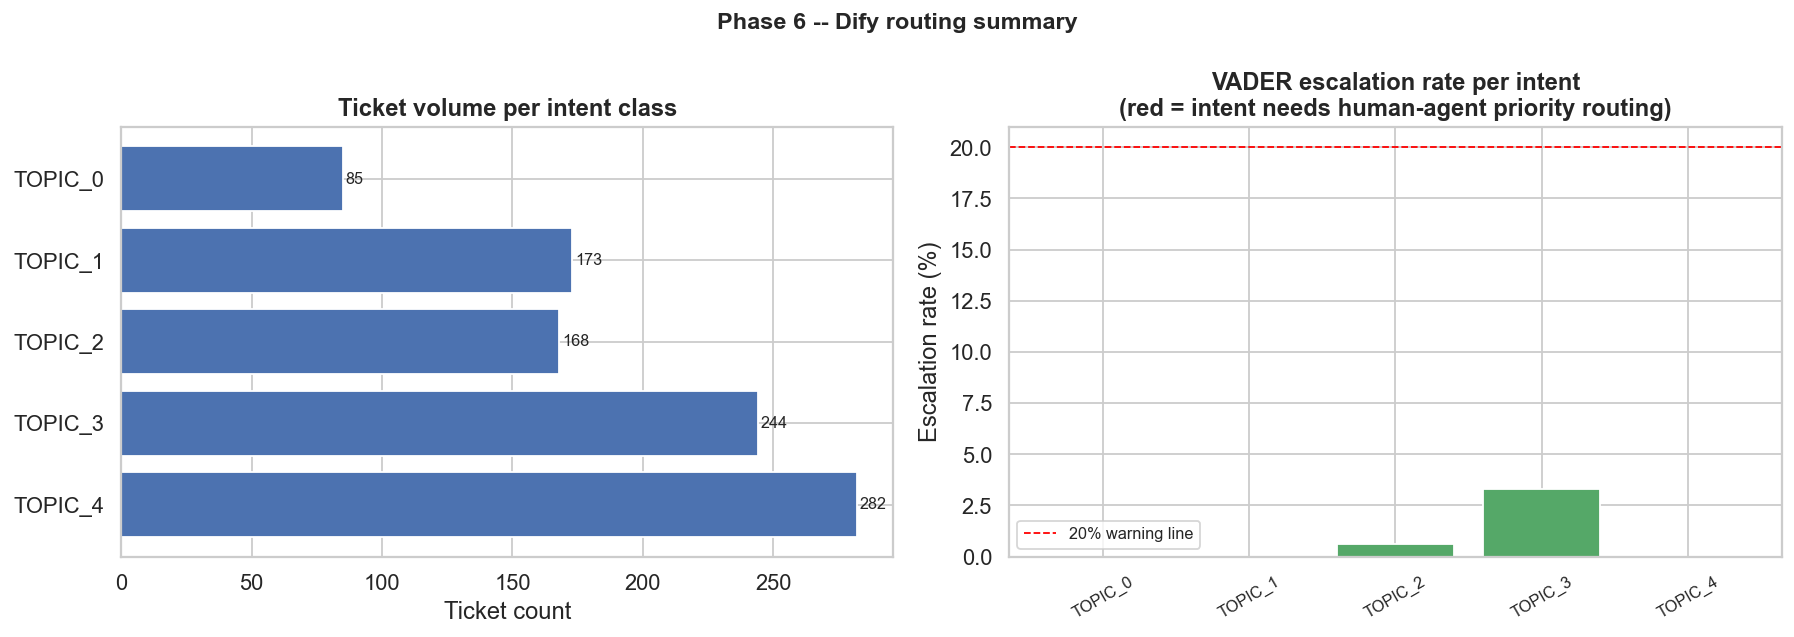

Saved: fig_06a_routing_summary.png


In [46]:
# Visual 6A: Intent volume + escalation rates
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vols   = [e['ticket_volume']  for e in intent_summary]
labels = [e['intent']         for e in intent_summary]
axes[0].barh(labels[::-1], vols[::-1],
              color=BRAND_COLORS[0], edgecolor='white')
for i, v in enumerate(vols[::-1]):
    axes[0].text(v + 1, i, str(v), va='center', fontsize=9)
axes[0].set_xlabel('Ticket count')
axes[0].set_title('Ticket volume per intent class', fontweight='bold')

esc_rates  = [e['escalation_rate'] for e in intent_summary]
bar_colors = [BRAND_COLORS[3] if r > 20 else BRAND_COLORS[2]
               for r in esc_rates]
axes[1].bar(labels, esc_rates, color=bar_colors, edgecolor='white')
axes[1].axhline(20, color='red', linestyle='--', linewidth=1,
                 label='20% warning line')
axes[1].set_ylabel('Escalation rate (%)')
axes[1].set_title('VADER escalation rate per intent\n'
                   '(red = intent needs human-agent priority routing)',
                   fontweight='bold')
axes[1].tick_params(axis='x', rotation=30, labelsize=9)
axes[1].legend(fontsize=9)

plt.suptitle('Phase 6 -- Dify routing summary', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_06a_routing_summary.png', bbox_inches='tight')
plt.show()
print('Saved: fig_06a_routing_summary.png')

In [47]:
# 6D: Dify workflow restructuring recommendations

print('='*70)
print('DIFY WORKFLOW RESTRUCTURING RECOMMENDATIONS')
print('='*70)
print('''
CURRENT ARCHITECTURE (from chatbot screenshots):
  START --> QUESTION CLASSIFIER (5 manual keyword classes)
         --> AskOS_[CLASS] --> CODE_[CLASS] --> ANSWER_[CLASS]

RECOMMENDED ARCHITECTURE:

  START
    |
    v
  [SENTIMENT PRE-CHECK]             NEW node -- Code node in Dify
    Keyword heuristic: check for    Use a Code node that scans for
    frustration keywords            urgency words and routes to
    ("urgent", "broken", "cannot"   HUMAN HANDOFF if triggered.
    combined with "still", "again")
    |
    v
  [QUESTION CLASSIFIER]             UPDATED with data-driven descriptions
    |--- CLASS 1 --> AskOS_[CLASS] --> Knowledge Retrieval --> ANSWER
    |--- CLASS 2 --> AskOs_[CLASS] --> Knowledge Retrieval --> ANSWER
    |--- CLASS N (LDA-discovered)
    |--- UNCLEAR (fallback)        --> CLARIFYING QUESTION node
                                       "Are you asking about X or Y?"

KEY CHANGES:
  1. Replace the 5 manual keyword classes with the data-driven class
     descriptions from dify_intent_taxonomy.csv (column: dify_description).

  2. Add an UNCLEAR fallback class. When the LLM cannot confidently route
     a question, it should trigger a clarifying question node, not guess.

  3. Add a sentiment pre-check Code node before the classifier.
     In Dify, use the Code node to match urgency keywords using Python:
     urgency_words = ["urgent", "critical", "broken", "error", "failed"]
     Route to human handoff if 2+ urgency words are present.

  4. Scope each Knowledge Retrieval node to its own class documents.
     Do NOT retrieve from all KB documents in every route -- this dilutes
     relevance scores and increases LLM hallucination risk.
''')
print('INTENTS NEEDING URGENT KB COVERAGE REVIEW (high escalation rate):')
for e in intent_summary:
    if e['escalation_rate'] > 15:
        print(f'  {e["intent"]}: {e["escalation_rate"]:.1f}% escalation')

DIFY WORKFLOW RESTRUCTURING RECOMMENDATIONS

CURRENT ARCHITECTURE (from chatbot screenshots):
  START --> QUESTION CLASSIFIER (5 manual keyword classes)
         --> AskOS_[CLASS] --> CODE_[CLASS] --> ANSWER_[CLASS]

RECOMMENDED ARCHITECTURE:

  START
    |
    v
  [SENTIMENT PRE-CHECK]             NEW node -- Code node in Dify
    Keyword heuristic: check for    Use a Code node that scans for
    frustration keywords            urgency words and routes to
    ("urgent", "broken", "cannot"   HUMAN HANDOFF if triggered.
    combined with "still", "again")
    |
    v
  [QUESTION CLASSIFIER]             UPDATED with data-driven descriptions
    |--- CLASS 1 --> AskOS_[CLASS] --> Knowledge Retrieval --> ANSWER
    |--- CLASS 2 --> AskOs_[CLASS] --> Knowledge Retrieval --> ANSWER
    |--- CLASS N (LDA-discovered)
    |--- UNCLEAR (fallback)        --> CLARIFYING QUESTION node
                                       "Are you asking about X or Y?"

KEY CHANGES:
  1. Replace the 5 manual keywo

---
## Executive Summary -- Stakeholder Findings

In [48]:
# Stakeholder summary
print('='*65)
print('ONESTREAM CHATBOT NLP ANALYSIS -- EXECUTIVE SUMMARY')
print('='*65)
print(f"""
DATASET
  Tickets analysed        : {len(df):,}
  Avg length (tokens)     : {df['clean_token_len'].mean():.0f} words after cleaning
  No category labels used -- fully unsupervised intent discovery

PHASE 2 -- EXPLORATORY NLP
  Top bigrams : {top_bigrams['bigram'].head(5).tolist()}
  Named entities: {len(ent_df):,} mentions across {ent_df['label'].nunique()} entity types
  VADER escalation candidates (compound < -0.5): {df['escalate_flag'].sum():,}

PHASE 3 -- LDA TOPIC DISCOVERY
  Optimal topics (data-driven): {best_k}
  Coherence score (c_v)       : {max(coherence_scores):.3f}
  Current Dify classifier has 5 manually chosen classes.
  Recommendation: update to {best_k} data-driven classes.

PHASE 4 -- KEYWORD EXTRACTION
  LR accuracy on LDA pseudo-labels : {lr_acc:.1%}
  Naive Bayes baseline             : {nb_acc:.1%}
  Discriminative keywords extracted for {len(classes)} classes.

PHASE 5 -- SEMANTIC EXPANSION
  word2vec vocabulary : {len(w2v.wv):,} tokens
  Keyword lists expanded with paraphrase variants.

OUTPUT FILES
  dify_intent_taxonomy.csv  -- paste-ready class descriptions for Dify
  w2v_tickets.model         -- trained word2vec model
  fig_00 to fig_06          -- all charts saved as PNG
""")
print('='*65)

ONESTREAM CHATBOT NLP ANALYSIS -- EXECUTIVE SUMMARY

DATASET
  Tickets analysed        : 1,826
  Avg length (tokens)     : 9 words after cleaning
  No category labels used -- fully unsupervised intent discovery

PHASE 2 -- EXPLORATORY NLP
  Top bigrams : ['test server', 'access test', 'lease module', 'test environment', 'imea imea']
  Named entities: 2,590 mentions across 6 entity types
  VADER escalation candidates (compound < -0.5): 48

PHASE 3 -- LDA TOPIC DISCOVERY
  Optimal topics (data-driven): 12
  Coherence score (c_v)       : 0.396
  Current Dify classifier has 5 manually chosen classes.
  Recommendation: update to 12 data-driven classes.

PHASE 4 -- KEYWORD EXTRACTION
  LR accuracy on LDA pseudo-labels : 89.0%
  Naive Bayes baseline             : 87.4%
  Discriminative keywords extracted for 5 classes.

PHASE 5 -- SEMANTIC EXPANSION
  word2vec vocabulary : 1,114 tokens
  Keyword lists expanded with paraphrase variants.

OUTPUT FILES
  dify_intent_taxonomy.csv  -- paste-ready 

---
## References

Blei, D. M., Ng, A. Y., & Jordan, M. I. (2003). Latent Dirichlet allocation. *Journal of Machine Learning Research, 3*, 993-1022.

Hutto, C. J., & Gilbert, E. (2014). VADER: A parsimonious rule-based model for sentiment analysis of social media text. *Proceedings of ICWSM*.

Jurafsky, D., & Martin, J. H. (2014). *Speech and language processing* (3rd ed. draft). Prentice Hall.

Manning, C. D., & Schütze, H. (2003). *Foundations of statistical natural language processing*. MIT Press.

Mikolov, T., Chen, K., Corrado, G., & Dean, J. (2013). Efficient estimation of word representations in vector space. *arXiv:1301.3781*.